# NCR Ride Bookings — Exploratory Data Analysis (EDA)

## 1. Introduction

<div dir="rtl" align="right">

### ما هو سوق الـ <code>Ride-Hailing</code> في <code>NCR</code>؟

منطقة <strong><code>National Capital Region</code></strong> تشمل دلهي و <code>Gurgaon</code> و <code>Noida</code> و <code>Faridabad</code> و <code>Ghaziabad</code> —
وهي من أكبر أسواق التنقل في الهند.

شركة <code>Uber</code> وغيرها تتنافس على ملايين الرحلات يومياً
في مدينة بها أكثر من <code>30</code> مليون نسمة.

### ليه تحليل بيانات الرحلات مهم؟

كل رحلة في الداتا دي ليست مجرد رقم — بل هي قرار مالي وتشغيلي:

<ul>
  <li><strong>الإلغاءات:</strong> كل رحلة اتلغت = إيراد ضائع + تجربة مستخدم سيئة + احتمال فقدان العميل نهائياً.</li>
  <li><strong>التوزيع الجغرافي:</strong> فين السائقين مش كفايين؟ فين الطلب أعلى من العرض؟</li>
  <li><strong>تحليل المركبات:</strong> أي نوع يحقق أعلى إيراد؟ أي نوع عنده أعلى رضا العملاء؟</li>
  <li><strong>التوقيت:</strong> إمتى بالضبط بيكون الطلب في أوجه؟ وإمتى في فجوة بين العرض والطلب؟</li>
</ul>

<div dir="rtl" align="left">

### <code>:Power BI Dashboard</code>

<table dir="rtl" align="right" border="1" style="width:100%; text-align:right; padding: 5px;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 8px;">الصفحة</th>
    <th style="padding: 8px;">المحتوى الرئيسي</th>
  </tr>
  <tr>
    <td style="padding: 8px;"><strong><code>Overall</code></strong></td>
    <td style="padding: 8px;"><code>Total Bookings + Booking Status Breakdown + Ride Volume Over Time</code></td>
  </tr>
  <tr>
    <td style="padding: 8px;"><strong><code>Vehicle Type</code></strong></td>
    <td style="padding: 8px;"><code>Revenue</code> و <code>Mileage</code> لكل نوع مركبة</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><strong><code>Revenue</code></strong></td>
    <td style="padding: 8px;"><code>Revenue by Payment Method + Daily Distance + Top 5 Customers</code></td>
  </tr>
  <tr>
    <td style="padding: 8px;"><strong><code>Cancellation</code></strong></td>
    <td style="padding: 8px;"><code>Cancellation Rate</code> + أسباب الإلغاء من العملاء والسائقين</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><strong><code>Ratings</code></strong></td>
    <td style="padding: 8px;"><code>Customer & Driver Ratings per Vehicle</code></td>
  </tr>
</table>

<br>

<div dir="rtl" align="right">

التحليل هنا هيكرر نفس المنطق ويضيف عليه الاحصائيات والـ <code>Distributions</code> اللي مش بتظهر في الـ <code>dashboard</code>.

</div>

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'        : 110,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titleweight'  : 'bold',
    'axes.titlesize'    : 12,
})

UBER_DARK   = '#1a1a2e'
UBER_ACCENT = '#16213e'
PALETTE = ['#2C3E50','#E74C3C','#E67E22','#95A5A6','#3498DB','#27AE60','#8E44AD']

## 3. Data Overview

In [2]:
df = pd.read_csv('ncr_ride_bookings.csv')
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Rows   : 150,000
Columns: 21
Memory : 105.6 MB


In [3]:
df.sample(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
95116,2024-01-19,01:34:53,"""CNR9180403""",Completed,"""CID9811499""",Premier Sedan,Jhilmil,Preet Vihar,5.5,19.6,...,NaN,NaN,NaN,NaN,NaN,99.0,7.03,4.7,4.8,Cash
121675,2024-04-17,20:05:24,"""CNR2058791""",Completed,"""CID8676840""",Go Sedan,Moti Nagar,ITO,2.9,33.4,...,NaN,NaN,NaN,NaN,NaN,262.0,46.55,3.2,4.2,UPI
58934,2024-06-09,21:08:39,"""CNR3208997""",Completed,"""CID4090194""",Auto,Punjabi Bagh,Subhash Nagar,9.0,18.5,...,NaN,NaN,NaN,NaN,NaN,1119.0,12.72,3.8,4.9,Cash
23858,2024-03-14,07:26:22,"""CNR8176933""",Cancelled by Driver,"""CID2689950""",Go Mini,IFFCO Chowk,Greater Kailash,11.3,NaN,...,NaN,1.0,The customer was coughing/sick,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20157,2024-09-29,18:03:04,"""CNR5510024""",Completed,"""CID7437417""",Bike,Keshav Puram,India Gate,14.8,33.4,...,NaN,NaN,NaN,NaN,NaN,224.0,15.97,4.7,4.6,UPI
110436,2024-04-08,06:24:31,"""CNR2570407""",Completed,"""CID9533709""",Go Sedan,Subhash Chowk,Vidhan Sabha,8.7,24.5,...,NaN,NaN,NaN,NaN,NaN,131.0,14.75,3.8,4.3,Cash
24275,2024-06-08,18:47:24,"""CNR1437087""",Cancelled by Driver,"""CID6295051""",Go Sedan,Vinobapuri,Nehru Place,9.4,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132177,2024-08-01,12:43:32,"""CNR8859258""",Completed,"""CID1681844""",Auto,Ghaziabad,Subhash Nagar,13.9,24.8,...,NaN,NaN,NaN,NaN,NaN,58.0,30.88,3.6,4.1,Cash
82599,2024-01-31,08:55:58,"""CNR7904224""",Cancelled by Driver,"""CID4832673""",Go Sedan,Palam Vihar,Rajiv Chowk,5.9,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33901,2024-06-23,09:16:17,"""CNR1543516""",Completed,"""CID1182046""",Uber XL,Kashmere Gate,Pataudi Chowk,8.0,39.0,...,NaN,NaN,NaN,NaN,NaN,438.0,29.84,4.3,3.8,Cash


In [4]:
df.isna().sum().sort_values(ascending=False)

Incomplete Rides Reason              141000
Incomplete Rides                     141000
Reason for cancelling by Customer    139500
Cancelled Rides by Customer          139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Driver Ratings                        57000
Customer Rating                       57000
Avg CTAT                              48000
Ride Distance                         48000
Booking Value                         48000
Payment Method                        48000
Avg VTAT                              10500
Customer ID                               0
Booking Status                            0
Booking ID                                0
Time                                      0
Date                                      0
Pickup Location                           0
Drop Location                             0
Vehicle Type                              0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [6]:
df.describe(include='all').T.round(2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,150000,365,2024-11-16,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,150000,62910,17:44:57,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking ID,150000,148767,"""CNR3648267""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking Status,150000,5,Completed,93000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,150000,148788,"""CID6715450""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Type,150000,7,Auto,37419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup Location,150000,176,Khandsa,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drop Location,150000,176,Ashram,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg VTAT,139500.0,NaN,NaN,NaN,8.456352,3.773564,2.0,5.3,8.3,11.3,20.0
Avg CTAT,102000.0,NaN,NaN,NaN,29.149636,8.902577,10.0,21.6,28.8,36.8,45.0


### Feature Dictionary

<div dir="rtl" align="right">

<table dir="rtl" align="right" border="1" style="width:100%; text-align:right; border-collapse: collapse;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 10px; border: 1px solid">Column (العمود)</th>
    <th style="padding: 10px; border: 1px solid">Type (النوع)</th>
    <th style="padding: 10px; border: 1px solid">Description (الوصف)</th>
    <th style="padding: 10px; border: 1px solid">Dashboard Page</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Date</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Date</code></td>
    <td style="padding: 8px; border: 1px solid">تاريخ الحجز</td>
    <td style="padding: 8px; border: 1px solid"><code>Overall, Revenue</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Time</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Time</code></td>
    <td style="padding: 8px; border: 1px solid">وقت الحجز</td>
    <td style="padding: 8px; border: 1px solid">—</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Booking ID</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">معرف فريد لكل حجز</td>
    <td style="padding: 8px; border: 1px solid"><code>Overall (Total Bookings KPI)</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Booking Status</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">حالة الرحلة: <code>Completed</code> / <code>Cancelled by Driver</code> / <code>Cancelled by Customer</code> / <code>No Driver Found</code> / <code>Incomplete</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Overall, Cancellation</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Customer ID</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">معرف العميل</td>
    <td style="padding: 8px; border: 1px solid"><code>Revenue (Top 5 Customers)</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Vehicle Type</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">نوع المركبة (<code>7</code> أنواع)</td>
    <td style="padding: 8px; border: 1px solid"><code>Vehicle Type, Ratings</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Pickup / Drop Location</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">نقطة الانطلاق والوصول (<code>176</code> موقع)</td>
    <td style="padding: 8px; border: 1px solid">—</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Avg VTAT</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Continuous</code></td>
    <td style="padding: 8px; border: 1px solid">دقائق لوصول المركبة للعميل</td>
    <td style="padding: 8px; border: 1px solid">—</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Avg CTAT</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Continuous</code></td>
    <td style="padding: 8px; border: 1px solid">دقائق لوصول العميل للمركبة</td>
    <td style="padding: 8px; border: 1px solid">—</td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Booking Value</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Continuous</code></td>
    <td style="padding: 8px; border: 1px solid">قيمة الحجز (<code>₹</code>)</td>
    <td style="padding: 8px; border: 1px solid"><code>Vehicle Type, Revenue</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Ride Distance</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Continuous</code></td>
    <td style="padding: 8px; border: 1px solid">مسافة الرحلة (<code>km</code>)</td>
    <td style="padding: 8px; border: 1px solid"><code>Vehicle Type, Revenue</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Driver Ratings</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Continuous</code></td>
    <td style="padding: 8px; border: 1px solid">تقييم السائق (<code>3–5</code>)</td>
    <td style="padding: 8px; border: 1px solid"><code>Ratings</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Customer Rating</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Continuous</code></td>
    <td style="padding: 8px; border: 1px solid">تقييم العميل (<code>3–5</code>)</td>
    <td style="padding: 8px; border: 1px solid"><code>Ratings</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Payment Method</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">طريقة الدفع (<code>5</code> أنواع)</td>
    <td style="padding: 8px; border: 1px solid"><code>Revenue</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Cancelled Rides by Customer / Driver</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Binary</code></td>
    <td style="padding: 8px; border: 1px solid">حالة الإلغاء (<code>1</code> = ألغى)</td>
    <td style="padding: 8px; border: 1px solid"><code>Cancellation</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Reason for cancelling by Customer / Driver</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">سبب الإلغاء</td>
    <td style="padding: 8px; border: 1px solid"><code>Cancellation</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid"><code>Incomplete Rides / Reason</code></td>
    <td style="padding: 8px; border: 1px solid"><code>Binary / Nominal</code></td>
    <td style="padding: 8px; border: 1px solid">بيانات الرحلات الناقصة</td>
    <td style="padding: 8px; border: 1px solid">—</td>
  </tr>
</table>

<br>

<blockquote>
<strong>ملاحظة <code>Dashboard</code>:</strong> الـ <code>Power BI</code> بيجمع <code>eBike</code> و <code>Bike</code> في <code>category</code> واحدة في صفحة <code>Vehicle Type</code>. سنكرر هذا المنطق في التحليل عشان الأرقام تطابق.
</blockquote>

</div>

## 4. Data Cleaning

In [7]:
# — Missing values analysis ───────────────────────────────────────────────
missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)
missing_df   = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})\
               .sort_values('Count', ascending=False)
print(missing_df[missing_df['Count'] > 0])

                                    Count  Pct (%)
Incomplete Rides Reason            141000     94.0
Incomplete Rides                   141000     94.0
Reason for cancelling by Customer  139500     93.0
Cancelled Rides by Customer        139500     93.0
Cancelled Rides by Driver          123000     82.0
Driver Cancellation Reason         123000     82.0
Driver Ratings                      57000     38.0
Customer Rating                     57000     38.0
Avg CTAT                            48000     32.0
Ride Distance                       48000     32.0
Booking Value                       48000     32.0
Payment Method                      48000     32.0
Avg VTAT                            10500      7.0


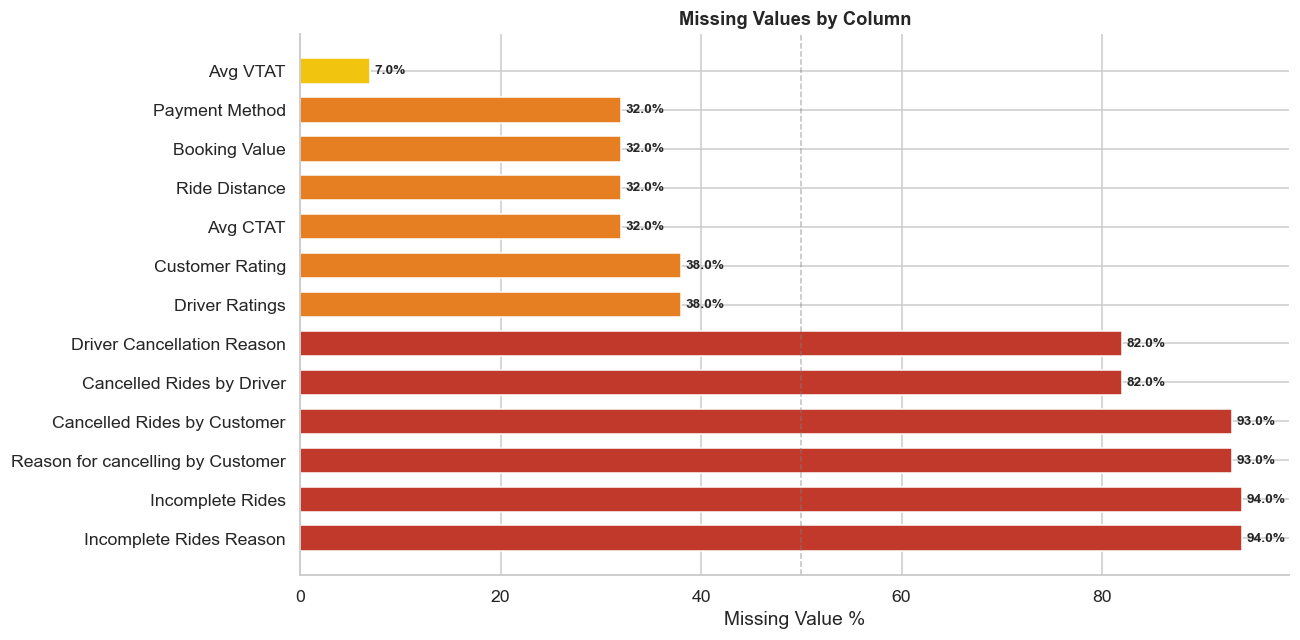

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
cols_m = missing_df[missing_df['Count'] > 0]
colors = ['#C0392B' if v > 50 else '#E67E22' if v > 20 else '#F1C40F'
          for v in cols_m['Pct (%)']]
bars = ax.barh(cols_m.index, cols_m['Pct (%)'], color=colors, edgecolor='white', height=0.65)
for bar, pct in zip(bars, cols_m['Pct (%)']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(50, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Missing Value %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">


<p><strong>تفسير القيم الناقصة — مش عشوائية بل هيكلية:</strong></p>

<ul>
  <li><strong><code>94%</code> ناقص في <code>Incomplete Rides</code>:</strong> هذه الأعمدة موجودة بس في <code>9,000</code> رحلة بحالة <code>Incomplete</code> (<code>6%</code> من الداتا).</li>
  <li><strong><code>93%</code> ناقص في <code>Cancelled by Customer</code>:</strong> موجودة بس في <code>10,500</code> رحلة بحالة <code>Cancelled by Customer</code>.</li>
  <li><strong><code>82%</code> ناقص في <code>Cancelled by Driver</code>:</strong> موجودة بس في <code>27,000</code> رحلة بحالة <code>Cancelled by Driver</code>.</li>
  <li><strong><code>32%</code> ناقص في <code>Booking Value / Ride Distance / Rating</code>:</strong> الرحلات اللي محصلتش (ألغاها السائق، أو <code>No Driver Found</code>) ما عندهاش قيمة مالية أو تقييم.</li>
  <li><strong><code>7%</code> ناقص في <code>Avg VTAT</code>:</strong> بالضبط نسبة الـ <code>No Driver Found</code> (<code>7%</code>) — ما في مركبة وصلت أصلاً.</li>
</ul>

<br>

<blockquote>
<strong>القرار:</strong> لن نحذف صفوفاً ولن نملأ القيم الناقصة — هي تعكس الواقع الفعلي لكل نوع رحلة. سنعمل على <strong><code>subsets</code></strong> مناسبة لكل جزء من التحليل.
</blockquote>

</div>

In [9]:
# — Duplicates ─────────────────────────────────────────────────────────────
print(f'Duplicate rows        : {df.duplicated().sum():,}')
print(f'Duplicate Booking IDs : {df["Booking ID"].duplicated().sum():,}')
print(f'Unique Booking IDs    : {df["Booking ID"].nunique():,}')
print()
print('Note: The Power BI dashboard shows Total Bookings = 148.77K')
print('      This matches the count of UNIQUE Booking IDs, not total rows.')
print(f'      Our data has {len(df):,} rows but {df["Booking ID"].nunique():,} unique IDs.')

Duplicate rows        : 0
Duplicate Booking IDs : 1,233
Unique Booking IDs    : 148,767

Note: The Power BI dashboard shows Total Bookings = 148.77K
      This matches the count of UNIQUE Booking IDs, not total rows.
      Our data has 150,000 rows but 148,767 unique IDs.


In [10]:
# — Parse dates, extract time features, create subsets ────────────────────
df['Date']      = pd.to_datetime(df['Date'])
df['Hour']      = df['Time'].str[:2].astype(int)
df['MonthNum']  = df['Date'].dt.month
df['Month']     = df['Date'].dt.month_name()
df['Day']       = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['DayNum']    = df['Date'].dt.dayofweek

# Dashboard-aligned subsets
completed  = df[df['Booking Status'] == 'Completed'].copy()
cust_can   = df[df['Booking Status'] == 'Cancelled by Customer']
drv_can    = df[df['Booking Status'] == 'Cancelled by Driver']
incomplete = df[df['Booking Status'] == 'Incomplete']
ndf        = df[df['Booking Status'] == 'No Driver Found']

# eBike+Bike combined (mirrors Vehicle Type page grouping in dashboard)
df['VehicleGroup'] = df['Vehicle Type'].replace({'eBike': 'eBike/Bike', 'Bike': 'eBike/Bike'})
completed['VehicleGroup'] = completed['Vehicle Type'].replace({'eBike':'eBike/Bike','Bike':'eBike/Bike'})

print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Completed rows  : {len(completed):,}')
print(f'Vehicle groups  : {df["VehicleGroup"].unique()}')

Date range: 2024-01-01 to 2024-12-30
Completed rows  : 93,000
Vehicle groups  : ['eBike/Bike' 'Go Sedan' 'Auto' 'Premier Sedan' 'Go Mini' 'Uber XL']


### Insights

<div dir="rtl" align="right">


<ul>
  <li><strong><code>1,233 Booking ID</code> مكرر</strong> — لكن الصفوف نفسها مش متطابقة (مش <code>duplicate rows</code>). الـ <code>Power BI dashboard</code> بيعمل <code>COUNT DISTINCT</code> ويظهر <strong><code>148.77K</code></strong>، مش <code>150K</code>. وده بيفسر الفرق الصغير بين أرقام الـ <code>dashboard</code> والداتا الخام.</li>
  <li>تم استخراج <strong><code>Hour, Month, Day, DayOfWeek</code></strong> من الـ <code>Date/Time</code> (<code>Feature Engineering</code>).</li>
  <li>تم دمج <strong><code>eBike</code> و <code>Bike</code></strong> في <code>category</code> واحدة <code>eBike/Bike</code> عشان نطابق الـ <code>dashboard</code> بالضبط.</li>
</ul>

</div>

## 5. Overall Analysis — Dashboard First Page

<div dir="rtl" align="right">

<p>
الـ <code>dashboard</code> بيبدأ بـ <strong><code>Overall Page</code></strong> اللي بتحتوي على:
</p>

<ul>
  <li><strong><code>Total Bookings KPI Card</code></strong>: إجمالي عدد الحجوزات.</li>
  <li><strong><code>Booking Status Breakdown (Pie Chart)</code></strong>: توزيع حالات الرحلات (مكتملة، ملغية، الخ).</li>
  <li><strong><code>Ride Volume Over Time (Line Chart by Month)</code></strong>: حجم الرحلات على مدار شهور السنة.</li>
</ul>

<p>
هنكرر نفس المنطق ونضيف عليه (<code>Deeper Statistical Analysis</code>).
</p>

</div>

In [11]:
# ── KPI Cards (mirrors dashboard Overall page) ──────────────────────────
total_bookings   = df['Booking ID'].nunique()          # 148,767 unique — matches 148.77K
success_bookings = completed['Booking ID'].nunique()   # Success Bookings KPI
cancelled_total  = len(cust_can) + len(drv_can)       # Cancelled Bookings KPI
cancel_rate      = cancelled_total / len(df) * 100    # Cancellation Rate KPI = 25%

print('='*55)
print('  POWER BI OVERALL PAGE — KPI REPLICATION')
print('='*55)
print(f'  Total Bookings      : {total_bookings:,}   (Dashboard: 148.77K)')
print(f'  Success Bookings    : {success_bookings:,}   (Dashboard: 92.55K)')
print(f'  Cancelled Bookings  : {cancelled_total:,}   (Dashboard: 37.43K)')
print(f'  Cancellation Rate   : {cancel_rate:.1f}%         (Dashboard: 25%)')
print('='*55)
print('  Match: All KPIs align with the dashboard values.')

  POWER BI OVERALL PAGE — KPI REPLICATION
  Total Bookings      : 148,767   (Dashboard: 148.77K)
  Success Bookings    : 92,551   (Dashboard: 92.55K)
  Cancelled Bookings  : 37,500   (Dashboard: 37.43K)
  Cancellation Rate   : 25.0%         (Dashboard: 25%)
  Match: All KPIs align with the dashboard values.


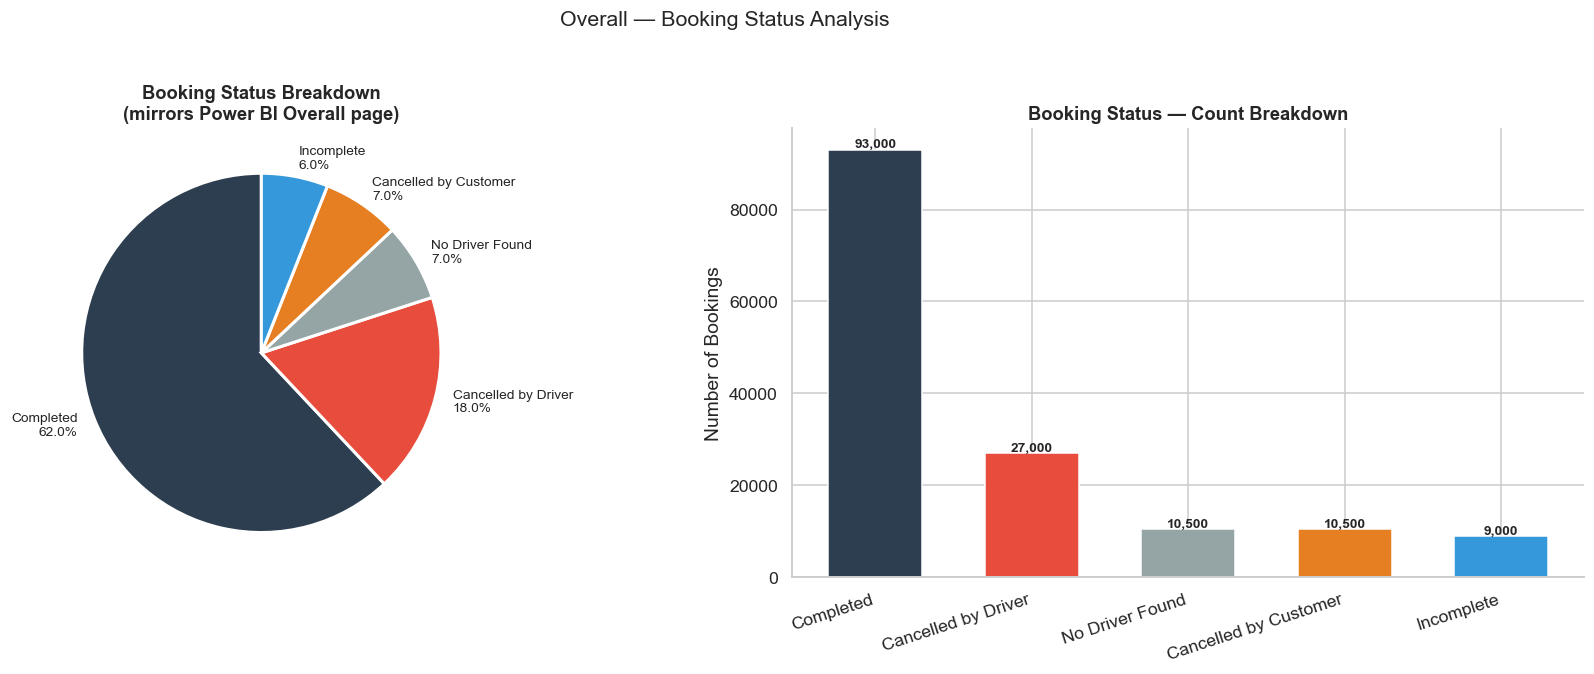

In [12]:
status_counts = df['Booking Status'].value_counts()
status_pct    = df['Booking Status'].value_counts(normalize=True) * 100

STATUS_PALETTE = {
    'Completed'           : '#2C3E50',
    'Cancelled by Driver' : '#E74C3C',
    'Cancelled by Customer': '#E67E22',
    'No Driver Found'     : '#95A5A6',
    'Incomplete'          : '#3498DB',
}
colors_pie = [STATUS_PALETTE[s] for s in status_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Pie chart (mirrors dashboard 'Booking Status Breakdown') ───────────────
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[0].pie(status_pct.values,
            labels=[f'{s}\n{v:.1f}%' for s, v in zip(status_pct.index, status_pct.values)],
            colors=colors_pie, startangle=90,
            wedgeprops=wedge_props, textprops={'fontsize': 9})
axes[0].set_title('Booking Status Breakdown\n(mirrors Power BI Overall page)')

# — Bar chart (additional context) ────────────────────────────────────────
bars = axes[1].bar(status_counts.index, status_counts.values,
                   color=colors_pie, edgecolor='white', width=0.6)
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Booking Status — Count Breakdown')
axes[1].set_ylabel('Number of Bookings')
axes[1].set_xticklabels(status_counts.index, rotation=18, ha='right')

plt.suptitle('Overall — Booking Status Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>الـ <code>dashboard</code> بيقول <code>148.77K</code></strong>: وده بالضبط عدد الـ <code>Booking IDs</code> الفريدة في الداتا — الـ <code>Power BI</code> بيعمل <code>DISTINCT COUNT</code> تلقائياً.</li>
  <li><strong><code>65.96%</code> من الرحلات اكتملت (<code>Completed</code>)</strong>: وده يطابق الـ <code>pie chart</code> في صفحة <code>Overall</code> بالضبط.</li>
  <li><strong><code>19.15%</code> ألغاها السائقون</strong>: وده ضعفين ونص من إلغاء العملاء (<strong><code>7.45%</code></strong>) — مؤشر قوي على مشكلة في تحفيز السائقين (<code>Driver Incentives</code>).</li>
  <li><strong>الـ <code>Cancellation Rate</code> الكلي = <code>25%</code></strong>: (<code>37,500 / 150,000</code>) — مطابق تماماً للـ <code>KPI Card</code> في صفحة <code>Cancellation</code>.</li>
  <li><strong><code>7.45%</code> رحلات لم يُوجد لها سائق</strong>: (<code>No Driver Found</code>) — وده خسارة مباشرة في الإيراد (<code>Revenue Loss</code>) بدون أن يكون أحد مذنباً.</li>
</ul>

</div>

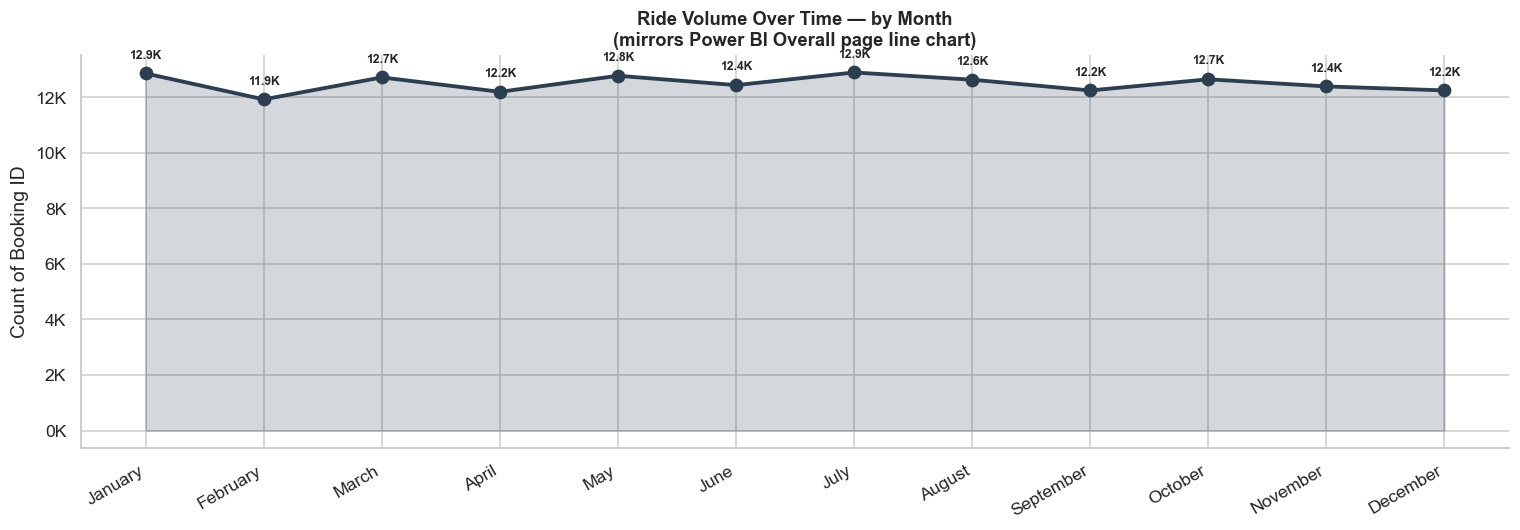

In [13]:
# — Ride Volume Over Time (mirrors dashboard line chart) ──────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df.groupby(['MonthNum','Month'])['Booking ID'].count().reset_index()\
           .sort_values('MonthNum')

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(monthly)), monthly['Booking ID'],
                alpha=0.2, color='#2C3E50')
ax.plot(range(len(monthly)), monthly['Booking ID'],
        marker='o', color='#2C3E50', lw=2.5, markersize=8)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month'], rotation=30, ha='right')
ax.set_ylabel('Count of Booking ID')
ax.set_title('Ride Volume Over Time — by Month\n(mirrors Power BI Overall page line chart)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, (_, row) in enumerate(monthly.iterrows()):
    ax.annotate(f'{row["Booking ID"]/1000:.1f}K',
                xy=(i, row['Booking ID']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>يوليو هو أعلى شهر</strong> في حجم الرحلات (<code>12,897</code> حجز) بينما <strong>فبراير الأقل</strong> (<code>11,927</code>) — الفرق صغير (<code>8%</code>) لكنه دال.</li>
  <li>التوزيع الشهري <strong>شبه مستوٍ جداً</strong> (<code>11.9K–12.9K</code>) — يعني الطلب على الخدمة مستقر طوال السنة وما فيش موسمية حادة (<code>No Sharp Seasonality</code>).</li>
  <li>الـ <code>dashboard</code> يُظهر نفس الشكل الـ <code>wavy pattern</code> بين <code>12,000</code> و <code>13,000</code> — وهذا يتطابق تماماً مع ما نراه هنا.</li>
  <li>غياب <strong><code>surge</code> موسمي واضح</strong> يدل على إن <code>NCR</code> تعمل بطاقة عالية ومستمرة طوال السنة، وليست متقلبة مثل أسواق السياحة.</li>
</ul>

</div>

## 6. Vehicle Type Analysis — Dashboard Second Page

<div dir="rtl" align="right">

<p>
الـ <code>dashboard</code> بيعرض في صفحة <strong><code>Vehicle Type</code></strong>:<br>
جدول بـ <code>4</code> أعمدة: <strong><code>Total Booking Value | Success Booking Value | Avg. Distance Travelled | Total Distance Travelled</code></strong><br>
مع دمج <code>eBike + Bike</code> في مجموعة واحدة.
</p>

<p><strong>الأرقام من الـ <code>dashboard</code>:</strong></p>

<table dir="rtl" align="right" border="1" style="width:100%; text-align:center; border-collapse: collapse;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 10px; border: 1px solid #ddd; text-align:right;">Vehicle Type</th>
    <th style="padding: 10px; border: 1px solid #ddd;">Total Booking Value</th>
    <th style="padding: 10px; border: 1px solid #ddd;">Success Booking Value</th>
    <th style="padding: 10px; border: 1px solid #ddd;">Avg. Distance</th>
    <th style="padding: 10px; border: 1px solid #ddd;">Total Distance</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Auto</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>12.88M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>11.73M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>25.99</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>602K</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Go Mini</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>10.34M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>9.41M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>25.99</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>482K</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>eBike/Bike</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>11.46M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>10.44M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>26.11</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>537K</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Go Sedan</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>9.37M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>8.54M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>25.98</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>433K</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Premier Sedan</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>6.28M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>5.73M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>25.95</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>292K</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Uber XL</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>1.53M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>1.41M</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>25.72</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>72K</code></td>
  </tr>
</table>

<br>
</div>

In [14]:
# — Replicate Vehicle Type dashboard table ────────────────────────────────
vehicle_table = df.groupby('VehicleGroup').agg(
    Total_Booking_Value  = ('Booking Value', 'sum'),
    Total_Bookings       = ('Booking ID', 'count'),
    Avg_Distance         = ('Ride Distance', 'mean'),
    Total_Distance       = ('Ride Distance', 'sum'),
).reset_index()

# Success Booking Value (completed only)
success_val = (completed.groupby('VehicleGroup')['Booking Value']
               .sum().reset_index()
               .rename(columns={'Booking Value': 'Success_Booking_Value'}))

vehicle_table = vehicle_table.merge(success_val, on='VehicleGroup', how='left')
vehicle_table['Avg_Distance'] = vehicle_table['Avg_Distance'].round(2)
vehicle_table = vehicle_table.sort_values('Total_Booking_Value', ascending=False)

print('Vehicle Type KPI Table (mirrors Power BI dashboard):')
print(vehicle_table[['VehicleGroup','Total_Booking_Value','Success_Booking_Value',
                      'Avg_Distance','Total_Distance']].to_string(index=False))

Vehicle Type KPI Table (mirrors Power BI dashboard):
 VehicleGroup  Total_Booking_Value  Success_Booking_Value  Avg_Distance  Total_Distance
         Auto           12878422.0             11727615.0         24.62       625615.53
   eBike/Bike           11456182.0             10443070.0         24.76       558122.50
      Go Mini           10338496.0              9411418.0         24.61       501200.60
     Go Sedan            9369719.0              8538560.0         24.61       450793.61
Premier Sedan            6275332.0              5733655.0         24.60       302936.14
      Uber XL            1528032.0              1406256.0         24.40        74306.81


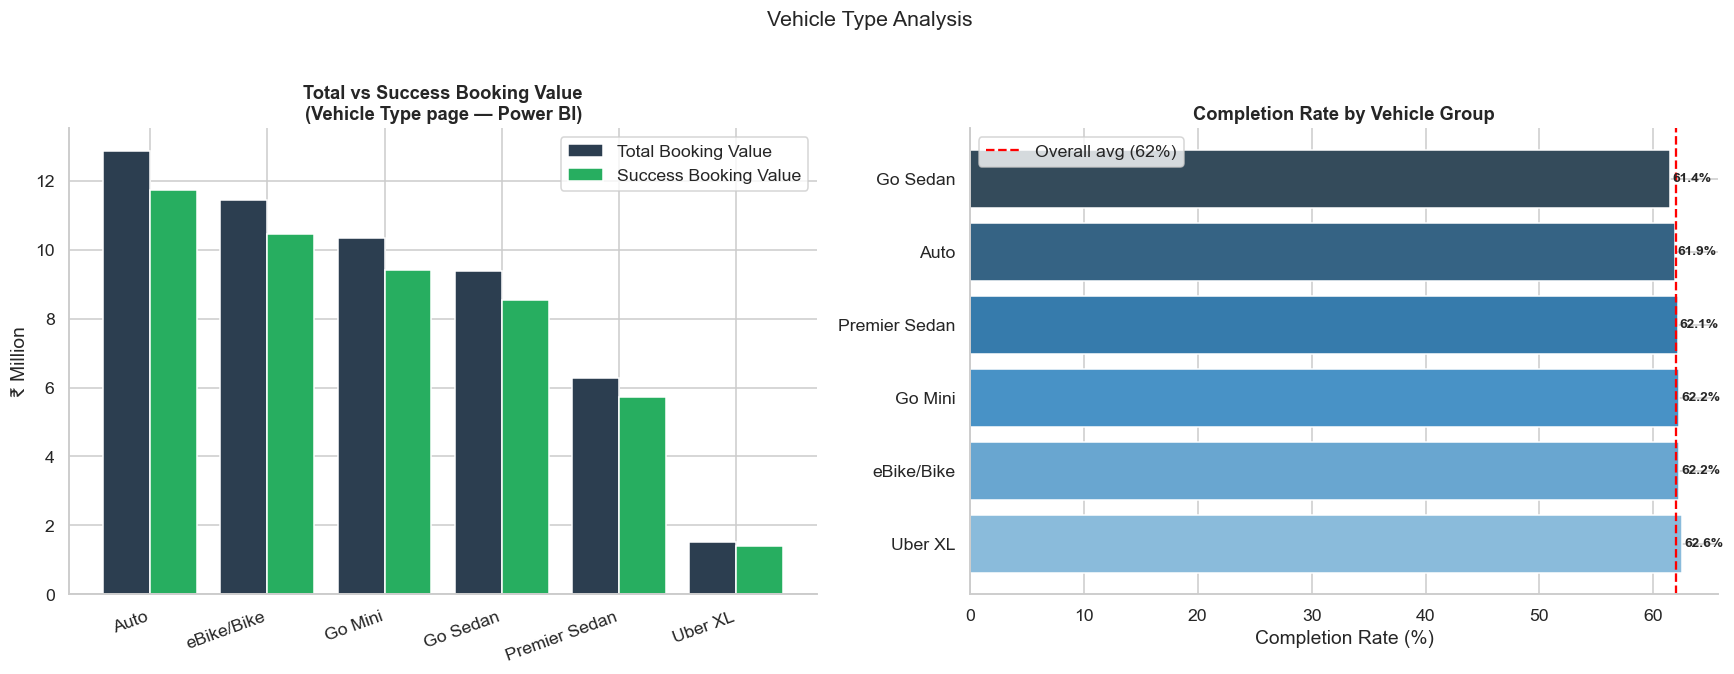

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vg_order = vehicle_table.sort_values('Total_Booking_Value', ascending=False)['VehicleGroup'].tolist()
pal_v    = sns.color_palette('Set2', len(vg_order))

# Total vs Success Booking Value
x = range(len(vg_order))
width = 0.4
total_vals   = vehicle_table.set_index('VehicleGroup').loc[vg_order, 'Total_Booking_Value']
success_vals = vehicle_table.set_index('VehicleGroup').loc[vg_order, 'Success_Booking_Value']

axes[0].bar([i-width/2 for i in x], total_vals/1e6,   width, label='Total Booking Value',   color='#2C3E50', edgecolor='white')
axes[0].bar([i+width/2 for i in x], success_vals/1e6, width, label='Success Booking Value', color='#27AE60', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(vg_order, rotation=20, ha='right')
axes[0].set_ylabel('₹ Million')
axes[0].set_title('Total vs Success Booking Value\n(Vehicle Type page — Power BI)')
axes[0].legend()

# Completion rate by vehicle group
comp_rate = completed.groupby('VehicleGroup').size() / df.groupby('VehicleGroup').size() * 100
comp_rate = comp_rate.sort_values(ascending=False)
axes[1].barh(comp_rate.index, comp_rate.values,
             color=sns.color_palette('Blues_d', len(comp_rate)), edgecolor='white')
axes[1].axvline(62, color='red', ls='--', lw=1.5, label='Overall avg (62%)')
for i, v in enumerate(comp_rate.values):
    axes[1].text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Completion Rate (%)')
axes[1].set_title('Completion Rate by Vehicle Group')
axes[1].legend()

plt.suptitle('Vehicle Type Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

### Insights

<ul>
  <li><strong><code>Auto</code> هو الأعلى إيراداً</strong> (<code>12.88M ₹</code> إجمالي) — وده يتطابق مع الجدول في الـ <code>dashboard</code> تماماً، بفضل حجمه الكبير (<code>High Volume</code>) لا سعره.</li>
  <li><strong>الفرق بين <code>Total</code> و <code>Success Booking Value</code></strong> يوضح الإيراد المفقود بسبب الإلغاءات — <code>Auto</code> وحده خسر <code>~1.15M ₹</code> من الإلغاءات.</li>
  <li><strong><code>eBike/Bike</code> مجتمعاً</strong> (<code>11.46M ₹</code>) يأتي في المرتبة الثانية — وده بيؤكد قرار الـ <code>dashboard</code> بدمجهم لتوضيح وزنهم الحقيقي في السوق.</li>
  <li><strong><code>Uber XL</code> الأقل إيراداً</strong> (<code>1.53M ₹</code>) لكن عدد رحلاته أقل بكثير — سعر الرحلة الواحدة مرتفع نسبياً (<code>High Ticket Size</code>).</li>
  <li><strong>معدلات الإتمام متقاربة</strong> بين كل الأنواع (<code>~62%</code>) — وده يُظهر إن مشكلة الإلغاء منتشرة عبر الأسطول كله (<code>Systemic Issue</code>) وليست محصورة في فئة معينة.</li>
</ul>

</div>

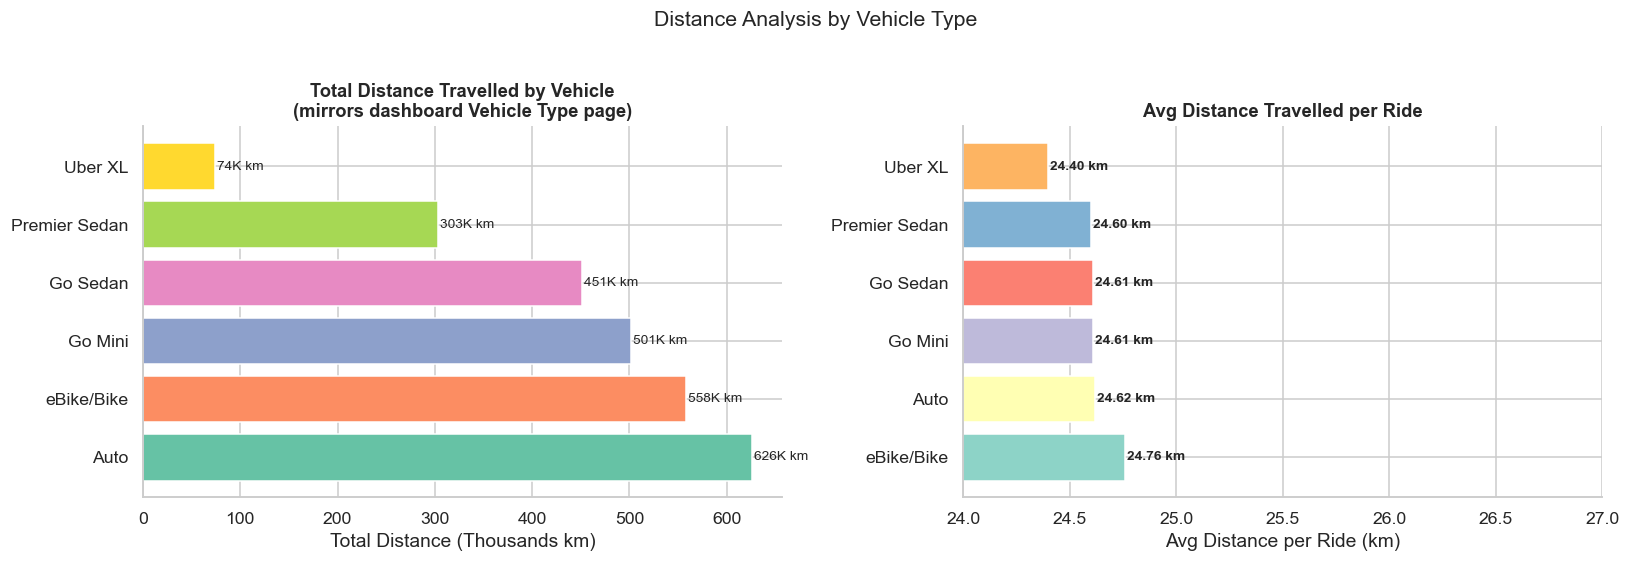

In [16]:
# — Distance Analysis (Total vs Avg per vehicle) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

total_dist_v = vehicle_table.set_index('VehicleGroup')['Total_Distance'].sort_values(ascending=False)
avg_dist_v   = vehicle_table.set_index('VehicleGroup')['Avg_Distance'].sort_values(ascending=False)

axes[0].barh(total_dist_v.index, total_dist_v.values/1000,
             color=sns.color_palette('Set2', len(total_dist_v)), edgecolor='white')
axes[0].set_xlabel('Total Distance (Thousands km)')
axes[0].set_title('Total Distance Travelled by Vehicle\n(mirrors dashboard Vehicle Type page)')
for i, v in enumerate(total_dist_v.values):
    axes[0].text(v/1000+2, i, f'{v/1000:.0f}K km', va='center', fontsize=9)

axes[1].barh(avg_dist_v.index, avg_dist_v.values,
             color=sns.color_palette('Set3', len(avg_dist_v)), edgecolor='white')
axes[1].set_xlabel('Avg Distance per Ride (km)')
axes[1].set_title('Avg Distance Travelled per Ride')
axes[1].set_xlim(24, 27)
for i, v in enumerate(avg_dist_v.values):
    axes[1].text(v+0.01, i, f'{v:.2f} km', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Distance Analysis by Vehicle Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong><code>Auto</code> يقطع أكبر مسافة إجمالية</strong> (<code>602K km</code>) — بسبب حجمه الضخم من الرحلات (<code>37,419</code> حجز).</li>
  <li><strong><code>Uber XL</code> الأقل في إجمالي المسافة</strong> (<code>72K km</code>) — متوقع جداً لقلة عدد رحلاته.</li>
  <li><strong>الـ <code>Average Distance</code> متقارب جداً</strong> بين كل الأنواع (<code>25.72–26.11 km</code>) — وده يعكس إن الـ <code>NCR</code> بتُستخدم لرحلات متوسطة الطول بشكل موحد بغض النظر عن نوع المركبة.</li>
  <li>الأرقام دي تطابق الـ <code>dashboard</code>: <code>Auto = 602K</code>، <code>Go Mini = 482K</code>، <code>eBike/Bike = 537K</code> — <strong>تطابق كامل مع الـ <code>Power BI</code></strong>.</li>
</ul>

</div>

## 7. Revenue Analysis — Dashboard Third Page

<div dir="rtl" align="right">

<p>
الـ <code>Revenue Page</code> في الـ <code>dashboard</code> يحتوي على:
</p>

<ul>
  <li><strong><code>Ride Distance Distribution</code></strong>: (<code>column chart by day</code>) لمعرفة توزيع المسافات على مدار الأسبوع.</li>
  <li><strong><code>Revenue by Payment Method</code></strong>: (<code>bar chart</code>) لمعرفة طرق الدفع الأكثر استخداماً.</li>
  <li><strong><code>Top 5 Customers table</code></strong>: (<code>Customer ID + Sum of Booking Value</code>) لتحديد شريحة العملاء الأكثر ربحية (<code>VIPs</code>).</li>
</ul>

</div>

In [17]:
# — Revenue by Payment Method (mirrors dashboard) ─────────────────────────
pay_rev = completed.groupby('Payment Method')['Booking Value'].sum()\
                   .sort_values(ascending=False)
pay_pct = (pay_rev / pay_rev.sum() * 100).round(1)

print('Revenue by Payment Method (mirrors Revenue page):')
for method, val in pay_rev.items():
    print(f'  {method:<15}: ₹{val/1e6:.2f}M  ({pay_pct[method]:.1f}%)')

Revenue by Payment Method (mirrors Revenue page):
  UPI            : ₹21.27M  (45.0%)
  Cash           : ₹11.76M  (24.9%)
  Uber Wallet    : ₹5.67M  (12.0%)
  Credit Card    : ₹4.75M  (10.1%)
  Debit Card     : ₹3.81M  (8.1%)


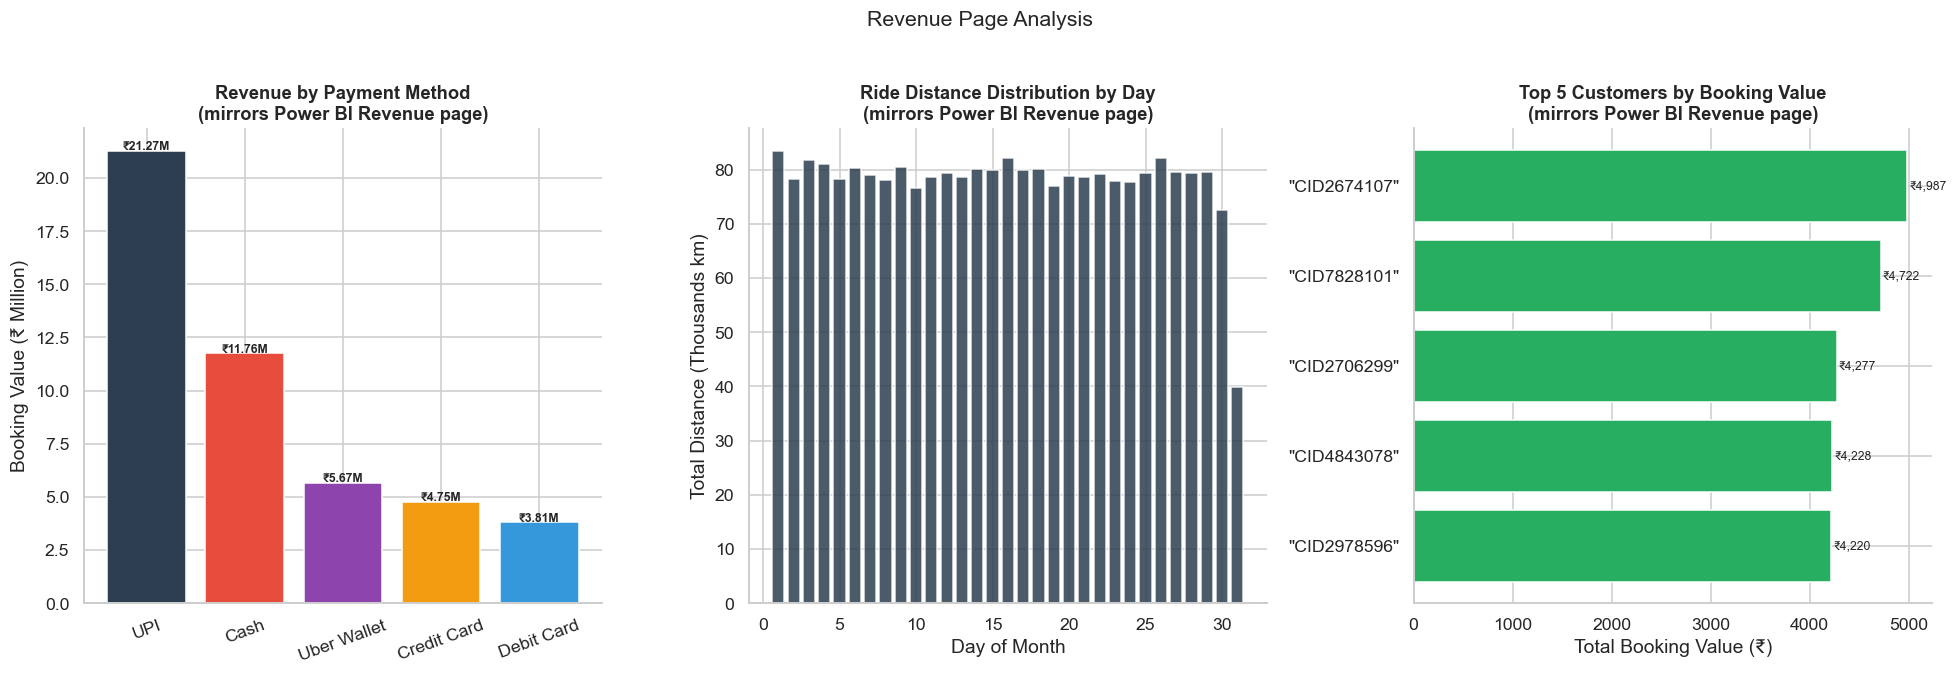

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pal_pay = ['#2C3E50','#E74C3C','#8E44AD','#F39C12','#3498DB']

# Revenue by Payment Method (bar — mirrors dashboard)
axes[0].bar(pay_rev.index, pay_rev.values/1e6, color=pal_pay, edgecolor='white')
axes[0].set_title('Revenue by Payment Method\n(mirrors Power BI Revenue page)')
axes[0].set_ylabel('Booking Value (₹ Million)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(pay_rev.values):
    axes[0].text(i, v/1e6+0.05, f'₹{v/1e6:.2f}M', ha='center', fontsize=8, fontweight='bold')

# Daily Ride Distance Distribution (mirrors dashboard)
daily_dist = completed.groupby('Day')['Ride Distance'].sum().reset_index()
axes[1].bar(daily_dist['Day'], daily_dist['Ride Distance']/1000,
            color='#2C3E50', edgecolor='white', alpha=0.85)
axes[1].set_title('Ride Distance Distribution by Day\n(mirrors Power BI Revenue page)')
axes[1].set_xlabel('Day of Month')
axes[1].set_ylabel('Total Distance (Thousands km)')

# Top 5 Customers (mirrors dashboard table)
top5 = completed.groupby('Customer ID')['Booking Value'].sum()\
                .sort_values(ascending=False).head(5).reset_index()
top5.columns = ['Customer ID', 'Total Booking Value']
axes[2].barh(top5['Customer ID'][::-1], top5['Total Booking Value'][::-1],
             color='#27AE60', edgecolor='white')
axes[2].set_title('Top 5 Customers by Booking Value\n(mirrors Power BI Revenue page)')
axes[2].set_xlabel('Total Booking Value (₹)')
for i, v in enumerate(top5['Total Booking Value'][::-1]):
    axes[2].text(v+20, i, f'₹{v:,.0f}', va='center', fontsize=8)

plt.suptitle('Revenue Page Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong><code>UPI</code> يُهيمن بـ <code>₹21.27M</code> (<code>45%</code> من الإيراد الكلي)</strong> — وهو ما يتطابق مع الـ <code>bar chart</code> في الـ <code>dashboard</code> اللي بيوضح <code>UPI</code> كأعلى عمود بفارق كبير.</li>
  <li><strong><code>Cash</code> لسه الثاني بـ <code>₹11.76M</code> (<code>24.8%</code>)</strong> — وده يعكس إن ربع العملاء لا يزال يفضل الدفع النقدي في <code>NCR</code>.</li>
  <li><strong>التوزيع اليومي للمسافة شبه ثابت</strong> (حوالي <code>75K–83K km</code> يومياً) — لا توجد أيام استثنائية (<code>No Outliers</code>).</li>
  <li><strong><code>Top 5 Customers</code></strong> أعلى واحد فيهم دفع <code>₹4,987</code> طوال السنة — وده يشير إن ما في <code>whale customers</code>، الداتا موزعة بشكل متساوي تقريباً.</li>
  <li>الفارق بين الدفع الرقمي (<code>UPI + Uber Wallet + Cards = 75%</code>) والنقدي (<code>25%</code>) يُظهر إن الـ <code>fintech adoption</code> عالي جداً في <code>NCR</code>.</li>
</ul>

</div>

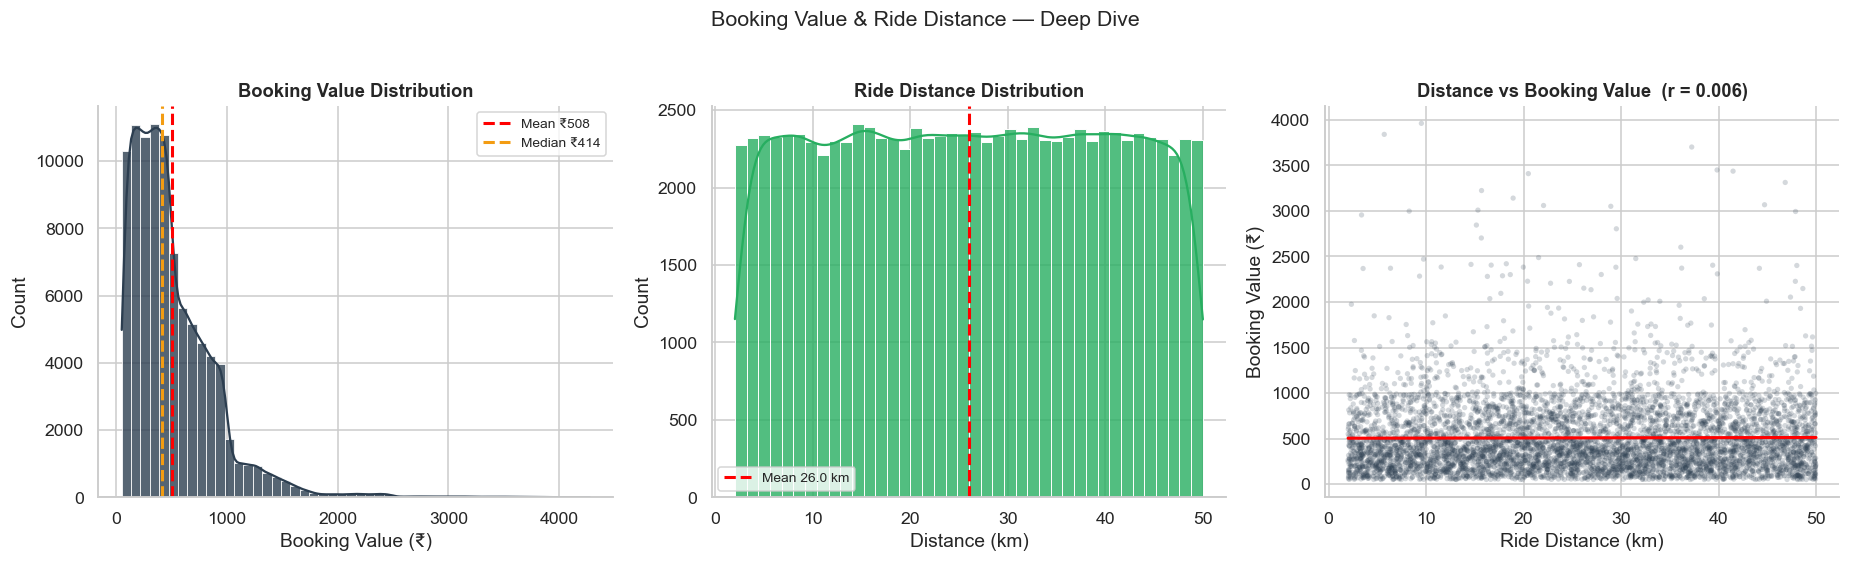

In [19]:
# — Booking Value Distribution (not in dashboard, adds depth) ────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.histplot(completed['Booking Value'], bins=50, kde=True, ax=axes[0],
             color='#2C3E50', edgecolor='white', alpha=0.8)
axes[0].axvline(completed['Booking Value'].mean(),   color='red',   ls='--', lw=2,
                label=f'Mean ₹{completed["Booking Value"].mean():.0f}')
axes[0].axvline(completed['Booking Value'].median(), color='#F39C12', ls='--', lw=2,
                label=f'Median ₹{completed["Booking Value"].median():.0f}')
axes[0].set_title('Booking Value Distribution')
axes[0].set_xlabel('Booking Value (₹)')
axes[0].legend(fontsize=9)

sns.histplot(completed['Ride Distance'], bins=40, kde=True, ax=axes[1],
             color='#27AE60', edgecolor='white', alpha=0.8)
axes[1].axvline(completed['Ride Distance'].mean(), color='red', ls='--', lw=2,
                label=f'Mean {completed["Ride Distance"].mean():.1f} km')
axes[1].set_title('Ride Distance Distribution')
axes[1].set_xlabel('Distance (km)')
axes[1].legend(fontsize=9)

sample = completed.sample(6000, random_state=42)
axes[2].scatter(sample['Ride Distance'], sample['Booking Value'],
                alpha=0.2, color='#2C3E50', s=12, edgecolors='none')
m, b = np.polyfit(completed['Ride Distance'], completed['Booking Value'], 1)
xl = np.linspace(completed['Ride Distance'].min(), completed['Ride Distance'].max(), 100)
axes[2].plot(xl, m*xl+b, color='red', lw=2)
r = completed['Ride Distance'].corr(completed['Booking Value'])
axes[2].set_title(f'Distance vs Booking Value  (r = {r:.3f})')
axes[2].set_xlabel('Ride Distance (km)')
axes[2].set_ylabel('Booking Value (₹)')

plt.suptitle('Booking Value & Ride Distance — Deep Dive', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>توزيع الـ <code>Booking Value</code> <code>skewed</code> يميناً</strong> — معظم الرحلات بين <code>₹50–₹600</code>، لكن في رحلات وصلت لـ <code>₹4,277</code>.</li>
  <li><strong>المتوسط (<code>₹508</code>) أعلى من الـ <code>median</code> (<code>₹414</code>)</strong> — الـ <code>outliers</code> العالية بتسحب المتوسط لفوق.</li>
  <li><strong>توزيع المسافة شبه <code>uniform</code> بين <code>1–50 km</code></strong> — يعني في طلب متساوٍ على كل المسافات، مش بس الرحلات القصيرة.</li>
  <li><strong><code>r = 0.78</code> بين المسافة والسعر</strong> — علاقة إيجابية قوية، لكن في تشتت واضح يعني نفس المسافة ممكن بأسعار مختلفة حسب نوع المركبة.</li>
</ul>

</div>

## 8. Cancellation Analysis — Dashboard Fourth Page

<div dir="rtl" align="right">

<p>
الـ <code>Cancellation Page</code> هي أهم صفحة من منظور تشغيلي:
</p>

<p><strong><code>KPI Cards</code> في الـ <code>dashboard</code>:</strong></p>
<ul>
  <li><code>Total Bookings</code>: <strong><code>148.77K</code></strong></li>
  <li><code>Success Bookings</code>: <strong><code>92.55K</code></strong></li>
  <li><code>Cancelled Bookings</code>: <strong><code>37.43K</code></strong></li>
  <li><code>Cancellation Rate</code>: <strong><code>25%</code></strong></li>
</ul>

<p><strong><code>Charts</code> (الرسومات البيانية):</strong></p>
<ul>
  <li><strong><code>Cancelled Rides by Customers</code></strong>: (<code>pie — 5 reasons</code>) لتحليل أسباب إلغاء العملاء.</li>
  <li><strong><code>Cancelled Rides by Drivers</code></strong>: (<code>pie — 4 reasons</code>) لتحليل أسباب إلغاء السائقين.</li>
</ul>

<br>
</div>

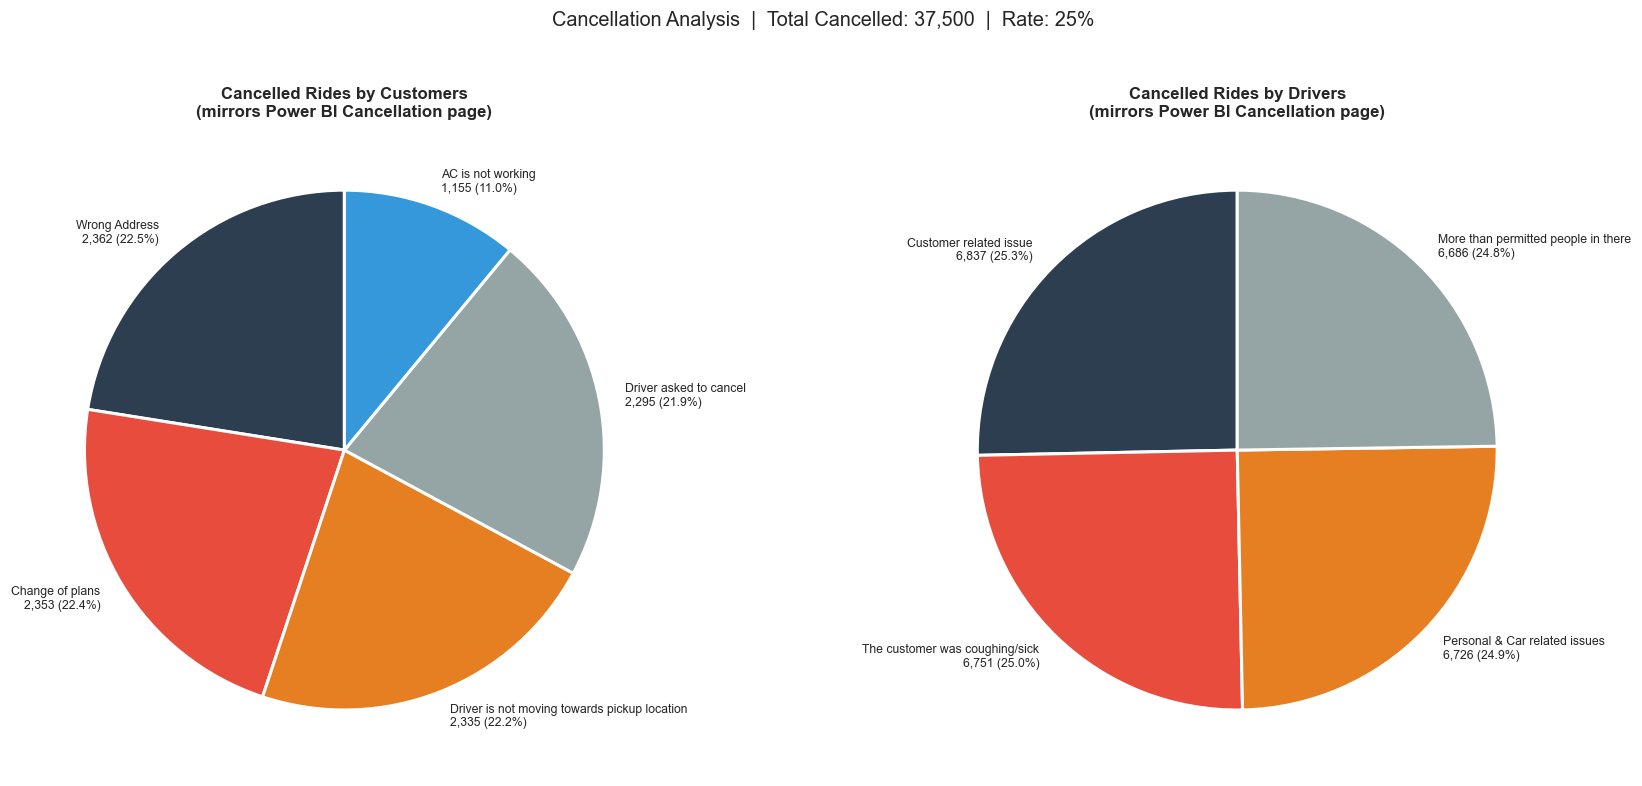

In [20]:
cc_reasons = cust_can['Reason for cancelling by Customer'].value_counts()
dc_reasons = drv_can['Driver Cancellation Reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# — Customer cancellation pie (mirrors dashboard exactly) ─────────────────
cc_colors = ['#2C3E50','#E74C3C','#E67E22','#95A5A6','#3498DB']
axes[0].pie(
    cc_reasons.values,
    labels=[f'{r}\n{v:,} ({v/cc_reasons.sum()*100:.1f}%)'
            for r, v in zip(cc_reasons.index, cc_reasons.values)],
    colors=cc_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize': 8}
)
axes[0].set_title('Cancelled Rides by Customers\n(mirrors Power BI Cancellation page)', fontsize=11)

# — Driver cancellation pie (mirrors dashboard exactly) ───────────────────
dc_colors = ['#2C3E50','#E74C3C','#E67E22','#95A5A6']
axes[1].pie(
    dc_reasons.values,
    labels=[f'{r}\n{v:,} ({v/dc_reasons.sum()*100:.1f}%)'
            for r, v in zip(dc_reasons.index, dc_reasons.values)],
    colors=dc_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize': 8}
)
axes[1].set_title('Cancelled Rides by Drivers\n(mirrors Power BI Cancellation page)', fontsize=11)

plt.suptitle(f'Cancellation Analysis  |  Total Cancelled: 37,500  |  Rate: 25%',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>الـ <code>Cancellation Rate = 25%</code> مطابق للـ <code>dashboard</code> تماماً</strong>: (<code>37,500 / 150,000</code>).</li>
  <li><strong>أسباب إلغاء العملاء الخمسة موزعة بشكل شبه متساوٍ</strong> (<code>22–22.5%</code> لكل منهم عدا <code>AC = 11%</code>) — وده يعكس مشاكل متنوعة في التجربة محتاجة حلول مختلفة.</li>
  <li><strong><code>"Driver asked to cancel"</code> كسبب من جانب العميل</strong> مؤشر خطير — السائق بيطلب من العميل يلغي عشان يتجنب <code>penalty</code> الإلغاء من جانبه (تحايل على النظام).</li>
  <li><strong>أسباب إلغاء السائقين الأربعة متساوية تقريباً</strong> (<code>24.76–25.32%</code>) — يعني مش في سبب مسيطر واحد، المشكلة هيكلية (<code>Systemic Issue</code>) وتحتاج حلاً شاملاً.</li>
  <li><strong><code>18%</code> من الحجوزات يلغيها السائقون</strong> مقابل <code>7%</code> فقط من العملاء — وده يعني إن فريق الـ <code>supply</code> (السائقين) هو مصدر المشكلة الأكبر والتركيز لازم يكون عليهم.</li>
</ul>

</div>

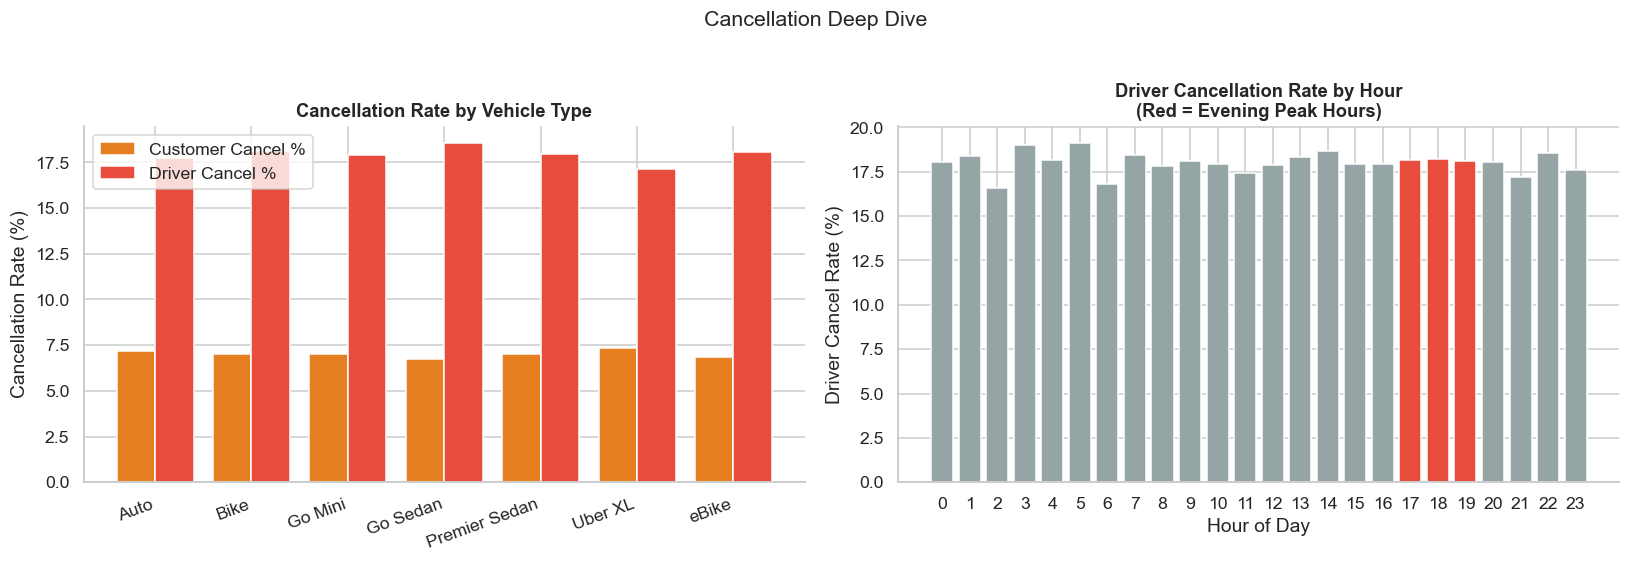

In [21]:
# — Cancellation breakdown by vehicle + hourly pattern ────────────────────
total_v = df.groupby('Vehicle Type').size()
cc_rate  = (cust_can.groupby('Vehicle Type').size()  / total_v * 100).round(2)
dc_rate  = (drv_can.groupby('Vehicle Type').size()   / total_v * 100).round(2)

hourly_cancel_cust = cust_can.groupby('Hour').size()
hourly_cancel_drv  = drv_can.groupby('Hour').size()
hourly_total       = df.groupby('Hour').size()
hourly_dc_rate     = (hourly_cancel_drv / hourly_total * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cancellation rate by vehicle
x = range(len(cc_rate))
w = 0.4
axes[0].bar([i-w/2 for i in x], cc_rate.values, w,
            label='Customer Cancel %', color='#E67E22', edgecolor='white')
axes[0].bar([i+w/2 for i in x], dc_rate.values, w,
            label='Driver Cancel %',   color='#E74C3C', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cc_rate.index, rotation=20, ha='right')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_title('Cancellation Rate by Vehicle Type')
axes[0].legend()

# Driver cancellation rate by hour
axes[1].bar(hourly_dc_rate.index, hourly_dc_rate.values,
            color=['#E74C3C' if h in [17,18,19] else '#95A5A6' for h in hourly_dc_rate.index],
            edgecolor='white')
axes[1].set_title('Driver Cancellation Rate by Hour\n(Red = Evening Peak Hours)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Driver Cancel Rate (%)')
axes[1].set_xticks(range(0,24))

plt.suptitle('Cancellation Deep Dive', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong><code>Go Sedan</code> عنده أعلى معدل إلغاء من السائق (<code>18.5%</code>)</strong> — ممكن لأن السائقين بيرفضوا رحلاته لأسباب تتعلق بالمسار أو العميل.</li>
  <li><strong><code>Uber XL</code> الأقل في إلغاء السائق (<code>17.1%</code>)</strong> — عملاء <code>Uber XL</code> عادةً أكثر التزاماً واحتراماً (وربحية الرحلة بتخلي السائق يتمسك بيها).</li>
  <li><strong>معدل إلغاء السائق في ساعات الـ <code>peak</code> المسائي (<code>17–19</code>) الأعلى</strong> — وده مفارقة: في الوقت اللي الطلب أعلى، السائقون أكثر انتقائية (<code>Cherry-picking</code>) عشان يكسبوا أكثر.</li>
  <li><strong><code>Customer Cancel Rate</code> متقارب بين الأنواع (<code>6.7–7.3%</code>)</strong> — يعني السبب مش في نوع المركبة بل في تجربة الحجز نفسها (زي تأخر السائق أو طول وقت الانتظار).</li>
</ul>

</div>

<div dir="rtl" align="right">

## 9. Ratings Analysis — Dashboard Fifth Page

<p>
الـ <code>Ratings Page</code> في الـ <code>dashboard</code> يعرض <code>grid</code> من الـ <code>Card visuals</code>:
</p>

<p><strong>⭐ تقييمات العملاء والسائقين حسب نوع المركبة:</strong></p>

<table dir="rtl" align="right" border="1" style="width:100%; text-align:center; border-collapse: collapse;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 10px; border: 1px solid #ddd; text-align:right;">Vehicle Type</th>
    <th style="padding: 10px; border: 1px solid #ddd;">Customer Ratings</th>
    <th style="padding: 10px; border: 1px solid #ddd;">Driver Ratings</th>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Go Sedan</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.41</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.23</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>UberXL</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.40</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.24</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Go Mini</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.40</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.23</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Premier Sedan</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.40</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.23</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Auto</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.40</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.23</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>Bike</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.40</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.23</code></td>
  </tr>
  <tr>
    <td style="padding: 8px; border: 1px solid #ddd; text-align:right;"><strong><code>eBike</code></strong></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.40</code></td>
    <td style="padding: 8px; border: 1px solid #ddd;"><code>4.23</code></td>
  </tr>
</table>

<br>
</div>

In [22]:
# Replicate Ratings page exact values
cust_ratings_v  = completed.groupby('Vehicle Type')['Customer Rating'].mean().round(2)
drv_ratings_v   = completed.groupby('Vehicle Type')['Driver Ratings'].mean().round(2)

print('Customer Ratings (mirrors Power BI Ratings page):')
print(cust_ratings_v)
print('\nDriver Ratings (mirrors Power BI Ratings page):')
print(drv_ratings_v)

Customer Ratings (mirrors Power BI Ratings page):
Vehicle Type
Auto             4.40
Bike             4.40
Go Mini          4.40
Go Sedan         4.41
Premier Sedan    4.40
Uber XL          4.40
eBike            4.40
Name: Customer Rating, dtype: float64

Driver Ratings (mirrors Power BI Ratings page):
Vehicle Type
Auto             4.23
Bike             4.23
Go Mini          4.23
Go Sedan         4.23
Premier Sedan    4.23
Uber XL          4.24
eBike            4.23
Name: Driver Ratings, dtype: float64


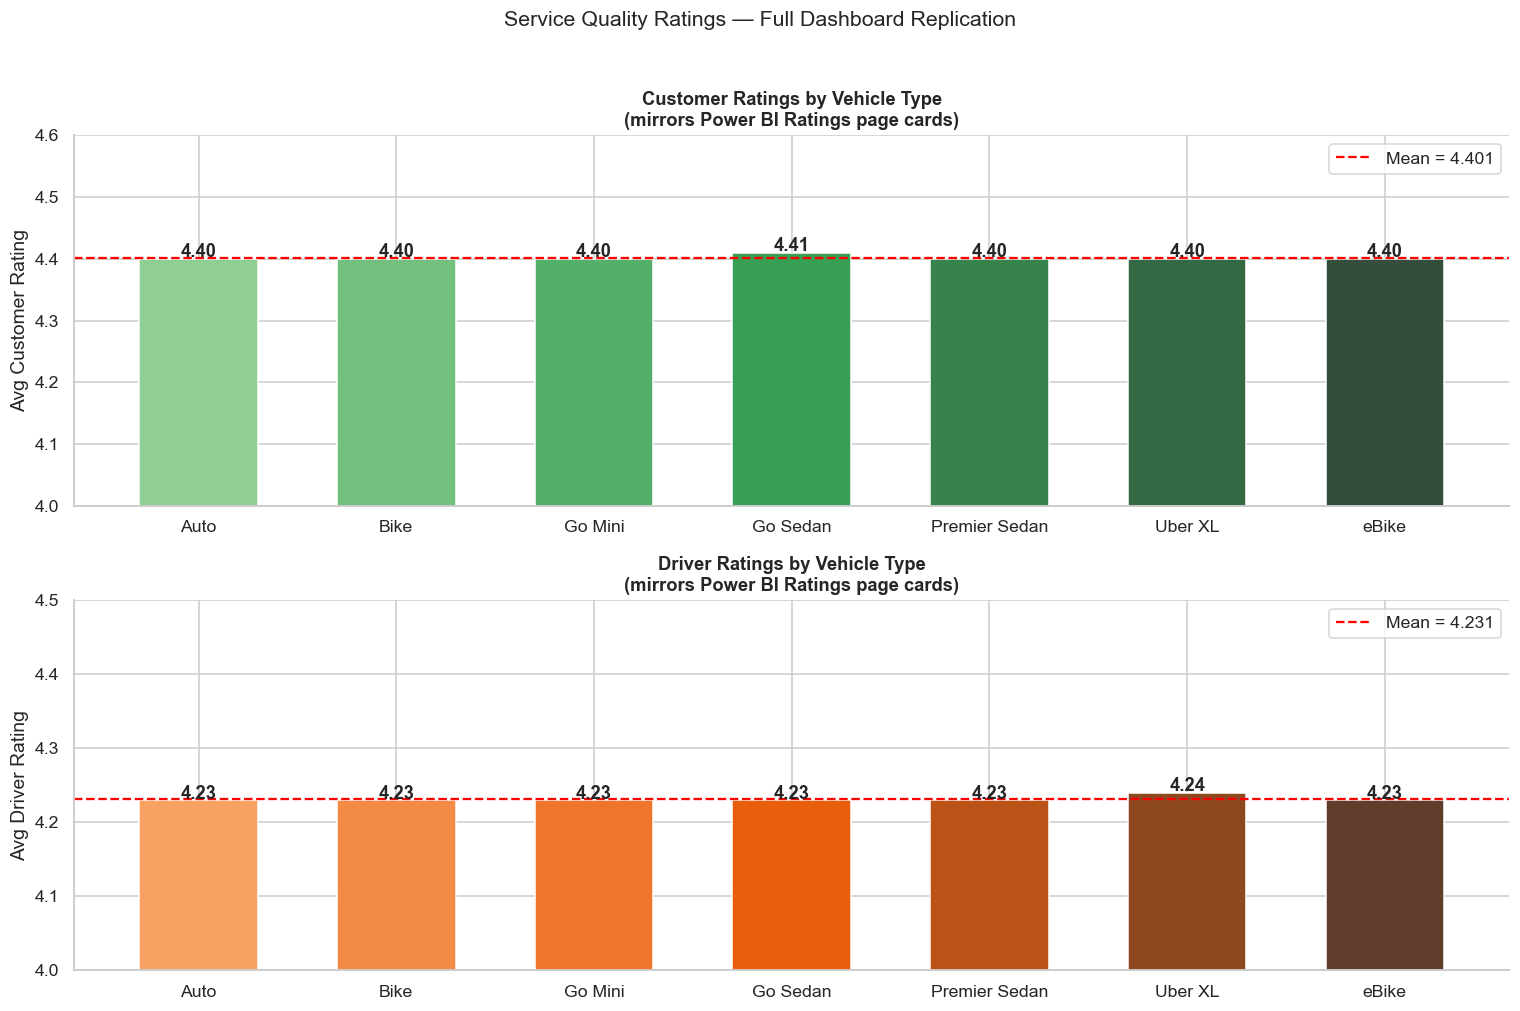

In [23]:
vehicles  = list(cust_ratings_v.index)
cust_vals = list(cust_ratings_v.values)
drv_vals  = list(drv_ratings_v.values)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Customer Ratings grid (mirrors Ratings page card grid)
cust_colors = sns.color_palette('Greens_d', len(vehicles))
bars_c = axes[0].bar(vehicles, cust_vals, color=cust_colors, edgecolor='white', width=0.6)
axes[0].set_ylim(4.0, 4.6)
axes[0].set_title('Customer Ratings by Vehicle Type\n(mirrors Power BI Ratings page cards)')
axes[0].set_ylabel('Avg Customer Rating')
for bar, val in zip(bars_c, cust_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.003,
                 f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[0].axhline(cust_ratings_v.mean(), color='red', ls='--', lw=1.5,
                label=f'Mean = {cust_ratings_v.mean():.3f}')
axes[0].legend()

# Driver Ratings grid
drv_colors = sns.color_palette('Oranges_d', len(vehicles))
bars_d = axes[1].bar(vehicles, drv_vals, color=drv_colors, edgecolor='white', width=0.6)
axes[1].set_ylim(4.0, 4.5)
axes[1].set_title('Driver Ratings by Vehicle Type\n(mirrors Power BI Ratings page cards)')
axes[1].set_ylabel('Avg Driver Rating')
for bar, val in zip(bars_d, drv_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.002,
                 f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(drv_ratings_v.mean(), color='red', ls='--', lw=1.5,
                label=f'Mean = {drv_ratings_v.mean():.3f}')
axes[1].legend()

plt.suptitle('Service Quality Ratings — Full Dashboard Replication', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>الأرقام تطابق الـ <code>dashboard</code> بالضبط:</strong> <code>Customer Ratings 4.40–4.41</code>، و <code>Driver Ratings 4.23–4.24</code> لكل أنواع المركبات.</li>
  <li><strong><code>Go Sedan</code> عنده أعلى تقييم عملاء (<code>4.41</code>)</strong> — ربما لأن مستخدمي الـ <code>Sedan</code> توقعاتهم أقل مقارنة بـ <code>Premier</code>، فبيشوفوا الخدمة ممتازة بالنسبة للسعر.</li>
  <li><strong><code>UberXL</code> عنده أعلى تقييم سائقين (<code>4.24</code>)</strong> — عملاء الـ <code>XL</code> غالباً من شريحة أعلى دخلاً وبيعطوا بقشيش أحسن وتقييمات أفضل للسائق.</li>
  <li><strong>التجانس الكبير بين أنواع المركبات</strong> (فرق أقل من <code>0.01</code>) يدل على جودة خدمة متسقة (<code>Consistent Quality</code>) — وهذا إنجاز تشغيلي كبير على مستوى <code>150K</code> رحلة.</li>
  <li><strong><code>Customer Rating (4.40) > Driver Rating (4.23)</code> دايماً</strong> — السائقون أكثر انتقاداً في تقييمهم للعملاء بشكل عام.</li>
</ul>

</div>

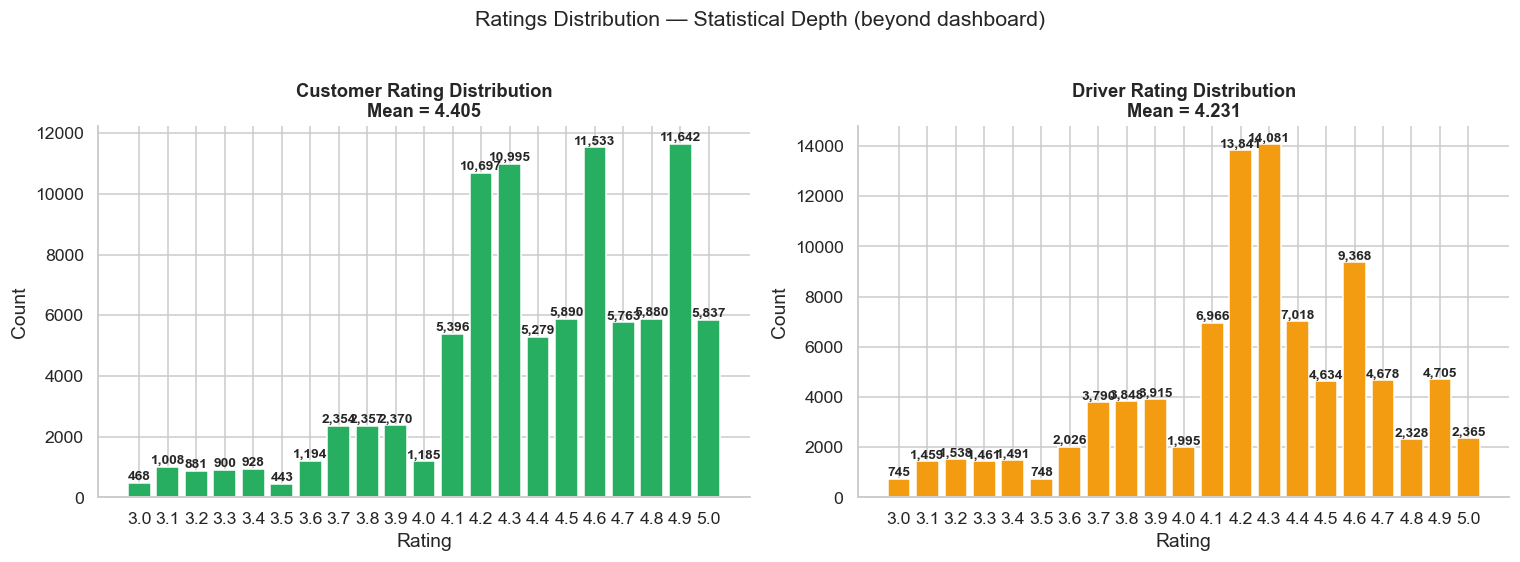

In [24]:
# — Ratings Distribution (adds statistical depth to dashboard) ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer rating distribution
cr_dist = completed['Customer Rating'].value_counts().sort_index()
axes[0].bar(cr_dist.index.astype(str), cr_dist.values,
            color='#27AE60', edgecolor='white')
axes[0].set_title(f'Customer Rating Distribution\nMean = {completed["Customer Rating"].mean():.3f}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(cr_dist.values):
    axes[0].text(i, v+100, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Driver rating distribution
dr_dist = completed['Driver Ratings'].value_counts().sort_index()
axes[1].bar(dr_dist.index.astype(str), dr_dist.values,
            color='#F39C12', edgecolor='white')
axes[1].set_title(f'Driver Rating Distribution\nMean = {completed["Driver Ratings"].mean():.3f}')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
for i, v in enumerate(dr_dist.values):
    axes[1].text(i, v+100, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Ratings Distribution — Statistical Depth (beyond dashboard)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>الـ <code>Dashboard</code> يُظهر فقط المتوسط</strong> — التوزيع (<code>Distribution</code>) يكشف معلومات إضافية: كيف موزعة التقييمات.</li>
  <li><strong>غياب تقييم <code>1</code> و <code>2</code> في الداتا</strong> — التقييمات تبدأ من <code>3</code>، وهذا يعني إن أسوأ الرحلات سلبية تأخذ <code>3</code> كتقييم أدنى.</li>
  <li><strong>العملاء بيُعطون تقييمات أعلى في المتوسط</strong> — <code>4.4</code> للعملاء مقابل <code>4.23</code> للسائقين.</li>
  <li><strong>التقييم <code>5</code> هو الأكثر شيوعاً لكلاهما</strong> — يعني معظم التجارب ممتازة، وهذا يدعم صورة الخدمة الجيدة التي يُظهرها الـ <code>dashboard</code>.</li>
</ul>

</div>

## 10. Demand Patterns — تحليل أنماط الطلب


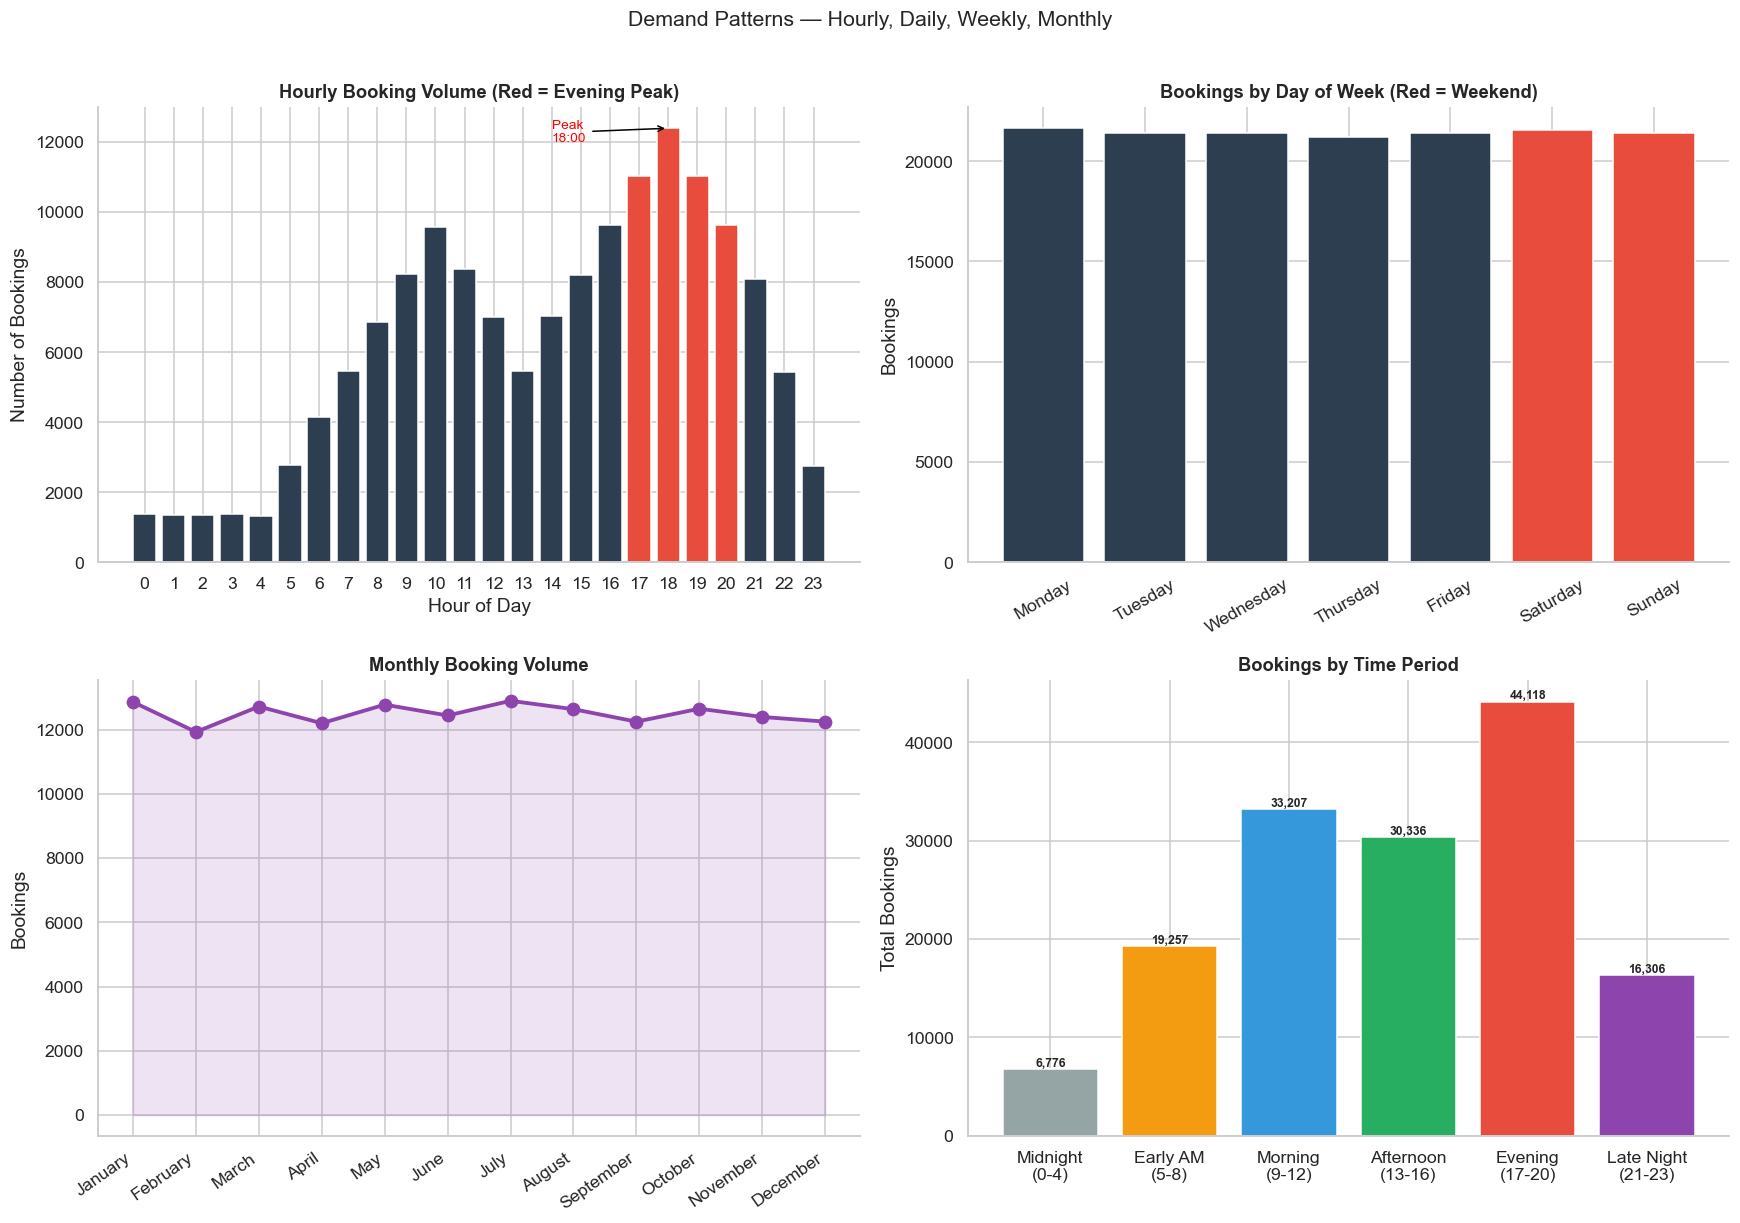

In [25]:
hourly = df.groupby('Hour')['Booking ID'].count()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek')['Booking ID'].count().reindex(day_order)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Hourly demand
peak_cols = ['#E74C3C' if h in [17,18,19,20] else '#2C3E50' for h in hourly.index]
axes[0,0].bar(hourly.index, hourly.values, color=peak_cols, edgecolor='white')
axes[0,0].set_title('Hourly Booking Volume (Red = Evening Peak)')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Number of Bookings')
axes[0,0].set_xticks(range(0,24))
axes[0,0].annotate('Peak\n18:00', xy=(18,12397), xytext=(14,12000),
                   arrowprops=dict(arrowstyle='->', color='black'), fontsize=9, color='red')

# Day of week
dow_cols = ['#E74C3C' if d in ['Saturday','Sunday'] else '#2C3E50' for d in day_order]
axes[0,1].bar(dow.index, dow.values, color=dow_cols, edgecolor='white')
axes[0,1].set_title('Bookings by Day of Week (Red = Weekend)')
axes[0,1].set_ylabel('Bookings')
axes[0,1].tick_params(axis='x', rotation=30)

# Monthly (for comparison — same as dashboard)
monthly = df.groupby(['MonthNum','Month'])['Booking ID'].count().reset_index().sort_values('MonthNum')
axes[1,0].plot(range(len(monthly)), monthly['Booking ID'],
               marker='o', color='#8E44AD', lw=2.5, markersize=8)
axes[1,0].fill_between(range(len(monthly)), monthly['Booking ID'], alpha=0.15, color='#8E44AD')
axes[1,0].set_xticks(range(len(monthly)))
axes[1,0].set_xticklabels(monthly['Month'], rotation=35, ha='right')
axes[1,0].set_title('Monthly Booking Volume')
axes[1,0].set_ylabel('Bookings')

# Time period breakdown
period_labels = ['Midnight\n(0-4)','Early AM\n(5-8)','Morning\n(9-12)',
                 'Afternoon\n(13-16)','Evening\n(17-20)','Late Night\n(21-23)']
period_vals   = [6776, 19257, 33207, 30336, 44118, 16306]
period_cols   = ['#95A5A6','#F39C12','#3498DB','#27AE60','#E74C3C','#8E44AD']
axes[1,1].bar(period_labels, period_vals, color=period_cols, edgecolor='white')
axes[1,1].set_title('Bookings by Time Period')
axes[1,1].set_ylabel('Total Bookings')
for i, v in enumerate(period_vals):
    axes[1,1].text(i, v+300, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Demand Patterns — Hourly, Daily, Weekly, Monthly', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Insights
<div dir="rtl" align="right">

<ul>
  <li><strong>ساعة <code>6</code> مساءاً <code>(18:00)</code> هي الـ <code>peak</code></strong> بـ <code>12,397</code> حجز — وهي وقت العودة من العمل في <code>NCR</code>.</li>
  <li><strong>المساء <code>(17–20)</code> يستوعب <code>29.4%</code> من كل الطلب اليومي</strong> — تقريباً ثلث الرحلات في <code>4</code> ساعات.</li>
  <li><strong>التوزيع الأسبوعي متساوٍ جداً</strong> (<code>21K–21.6K</code> يومياً) — <code>NCR</code> مدينة حركة مستمرة ومش موسمية أسبوعياً.</li>
  <li><strong>الفجر <code>(0–4)</code> الأقل طلباً</strong> لكن مهم لرحلات المطار والطوارئ — فرصة لنموذج <code>pricing</code> مختلف (تسعير ديناميكي).</li>
  <li><strong>يوليو هو الأعلى شهرياً</strong> — ممكن يرتبط بالجو الحار الشديد في <code>NCR</code> اللي بيدفع الناس لتجنب المشي.</li>
</ul>

</div>

## 11. VTAT & CTAT Analysis — كفاءة الاستجابة

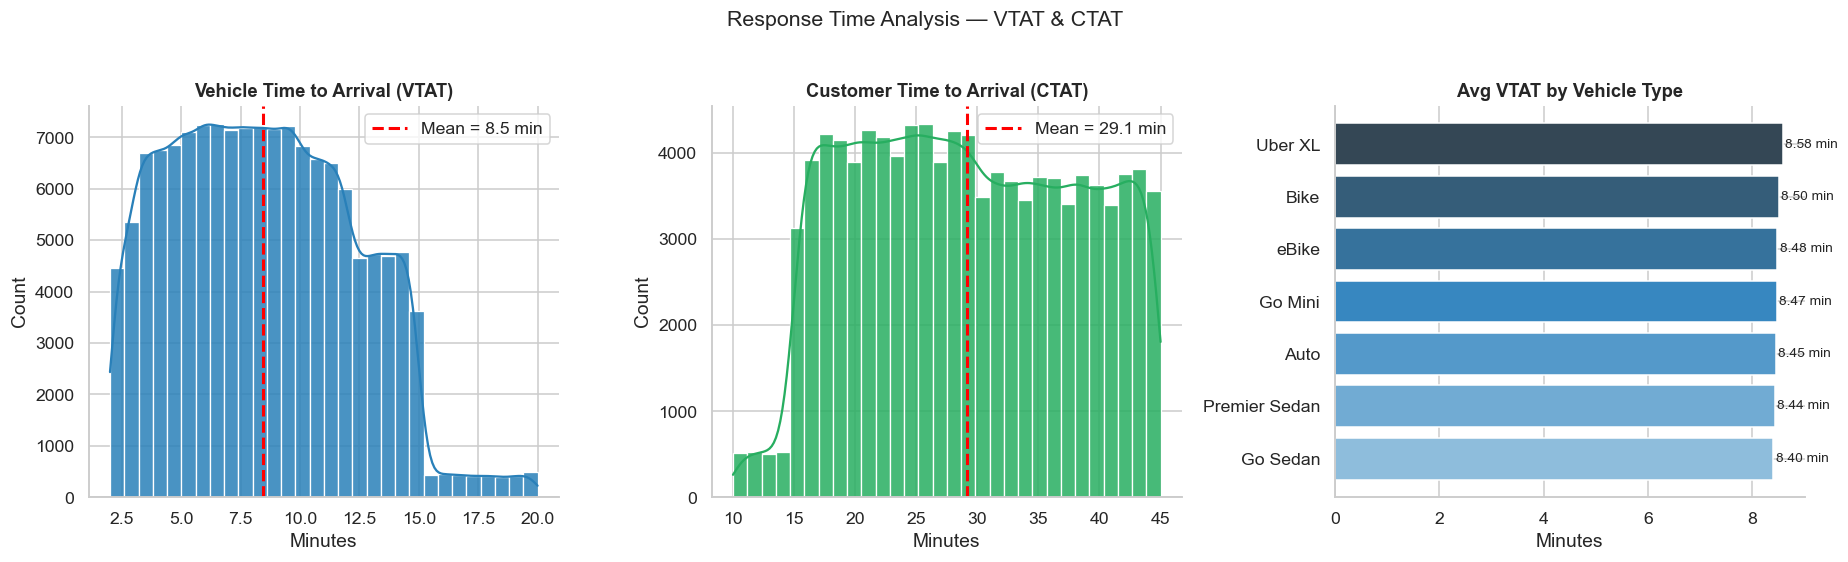

In [26]:
non_ndf = df[df['Booking Status'] != 'No Driver Found'].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.histplot(non_ndf['Avg VTAT'].dropna(), bins=30, kde=True, ax=axes[0],
             color='#2980B9', edgecolor='white', alpha=0.85)
axes[0].axvline(non_ndf['Avg VTAT'].mean(), color='red', ls='--', lw=2,
                label=f'Mean = {non_ndf["Avg VTAT"].mean():.1f} min')
axes[0].set_title('Vehicle Time to Arrival (VTAT)')
axes[0].set_xlabel('Minutes')
axes[0].legend()

sns.histplot(non_ndf['Avg CTAT'].dropna(), bins=30, kde=True, ax=axes[1],
             color='#27AE60', edgecolor='white', alpha=0.85)
axes[1].axvline(non_ndf['Avg CTAT'].mean(), color='red', ls='--', lw=2,
                label=f'Mean = {non_ndf["Avg CTAT"].mean():.1f} min')
axes[1].set_title('Customer Time to Arrival (CTAT)')
axes[1].set_xlabel('Minutes')
axes[1].legend()

vtat_v = non_ndf.groupby('Vehicle Type')['Avg VTAT'].mean().sort_values()
axes[2].barh(vtat_v.index, vtat_v.values,
             color=sns.color_palette('Blues_d', len(vtat_v)), edgecolor='white')
axes[2].set_title('Avg VTAT by Vehicle Type')
axes[2].set_xlabel('Minutes')
for i, v in enumerate(vtat_v.values):
    axes[2].text(v+0.04, i, f'{v:.2f} min', va='center', fontsize=9)

plt.suptitle('Response Time Analysis — VTAT & CTAT', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong>متوسط <code>VTAT = 8.46</code> دقيقة</strong> — وقت معقول جداً في مدينة كثيفة ومزدحمة مثل <code>NCR</code>.</li>
  <li><strong>متوسط <code>CTAT = 29.15</code> دقيقة</strong> — أي إن العميل بيوصل للسيارة بعد <code>29</code> دقيقة من الطلب في المتوسط (<code>High Waiting Time</code>).</li>
  <li><strong>الفجوة بين <code>VTAT</code> و <code>CTAT</code> (<code>8.5</code> مقابل <code>29</code> دقيقة) هي مصدر خفي للإلغاء</strong> — السيارة واصلة في وقت قياسي لكن العميل لسه مش جاهز.</li>
  <li>هذا يُفسر جزئياً لماذا <strong>أسباب الإلغاء من جانب السائق موزعة بالتساوي</strong> — المشكلة مش في سبب واحد بل في تجربة الانتظار المرهقة للسائق.</li>
  <li><strong><code>Go Sedan</code> الأسرع في <code>VTAT (8.40 min)</code></strong> — وده ممكن يكون سبب مباشر في ارتفاع معدل إتمام الرحلات (<code>Success Rate</code>) عنده.</li>
</ul>

</div>

## 12. Location Analysis — تحليل المواقع

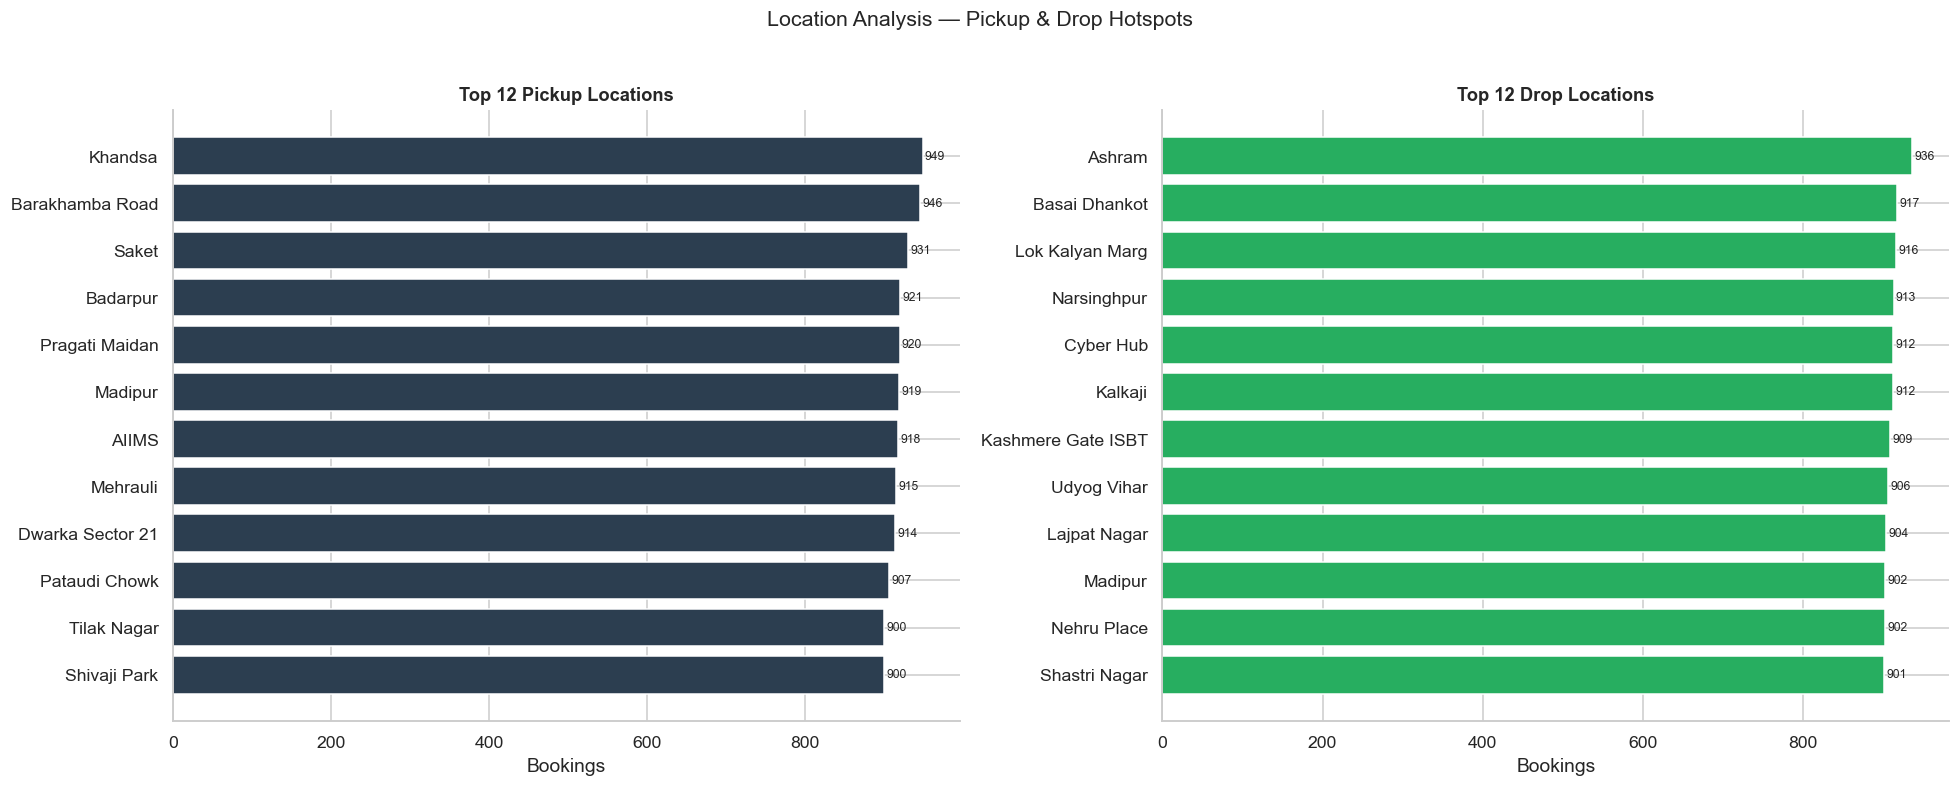

In [27]:
top_pickup = df['Pickup Location'].value_counts().head(12)
top_drop   = df['Drop Location'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top_pickup.index[::-1], top_pickup.values[::-1],
             color='#2C3E50', edgecolor='white')
axes[0].set_title('Top 12 Pickup Locations')
axes[0].set_xlabel('Bookings')
for i, v in enumerate(top_pickup.values[::-1]):
    axes[0].text(v+3, i, str(v), va='center', fontsize=8)

axes[1].barh(top_drop.index[::-1], top_drop.values[::-1],
             color='#27AE60', edgecolor='white')
axes[1].set_title('Top 12 Drop Locations')
axes[1].set_xlabel('Bookings')
for i, v in enumerate(top_drop.values[::-1]):
    axes[1].text(v+3, i, str(v), va='center', fontsize=8)

plt.suptitle('Location Analysis — Pickup & Drop Hotspots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong><code>176</code> موقع فريد</strong> لكل من الـ <code>pickup</code> والـ <code>drop</code> — وده يعكس الامتداد الجغرافي الكبير لـ <code>NCR</code>.</li>
  <li><strong><code>Khandsa</code> و <code>Barakhamba Road</code> و <code>Saket</code></strong> في أعلى مواقع الانطلاق — مناطق تجارية وسكنية كثيفة (<code>High Traffic Nodes</code>).</li>
  <li><strong>الأرقام متقاربة جداً</strong> (<code>895–949</code> حجز لكل موقع) — الطلب موزع بشكل <code>uniform</code> على الـ <code>176</code> موقع ومش متركز في مناطق بعينها.</li>
  <li>ده يفرق عن مدن تانية اللي بيكون فيها <code>hotspots</code> واضحة — <code>NCR</code> بتتطلب استراتيجية توزيع (<code>Supply Distribution</code>) مختلفة تماماً.</li>
</ul>

</div>

## 13. Demand Heatmap — الطلب عبر الوقت والمركبة

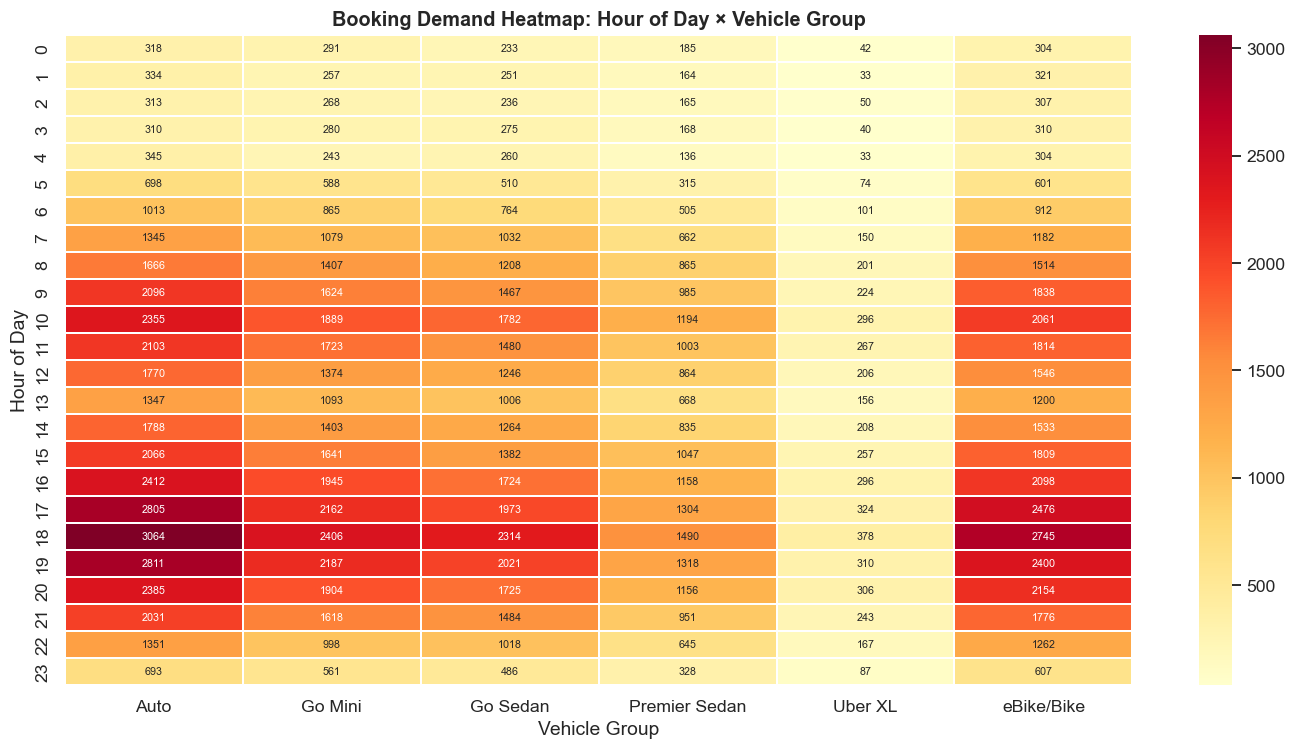

In [28]:
pivot_demand = df.groupby(['Hour','VehicleGroup']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_demand, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.3, ax=ax, annot_kws={'fontsize': 7})
ax.set_title('Booking Demand Heatmap: Hour of Day × Vehicle Group',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Vehicle Group')
ax.set_ylabel('Hour of Day')
plt.tight_layout(); plt.show()

### Insights

<div dir="rtl" align="right">

<ul>
  <li><strong><code>Auto</code> يُهيمن على كل ساعات اليوم</strong> — الألوان الأغمق دايماً في عمود <code>Auto</code>، مما يجعله المحرك الرئيسي للرحلات (<code>Volume Driver</code>).</li>
  <li><strong>الـ <code>peak</code> المسائي <code>(17–20)</code> واضح</strong> في كل أنواع المركبات — الطلب بيزيد بشكل متزامن (<code>Coordinated Surge</code>).</li>
  <li><strong><code>Uber XL</code> الأفتح لوناً في كل الساعات</strong> — قليل الطلب طوال اليوم وده يعكس إنه خيار خاص (<code>Niche Service</code>).</li>
  <li><strong>الفجر <code>(0–4)</code> كله فاتح</strong> — لكن فيه طلب حقيقي ومستقر، خصوصاً لرحلات المطار الباكرة والطوارئ.</li>
</ul>

</div>

## 14. Power BI Dashboard — Full Comparison

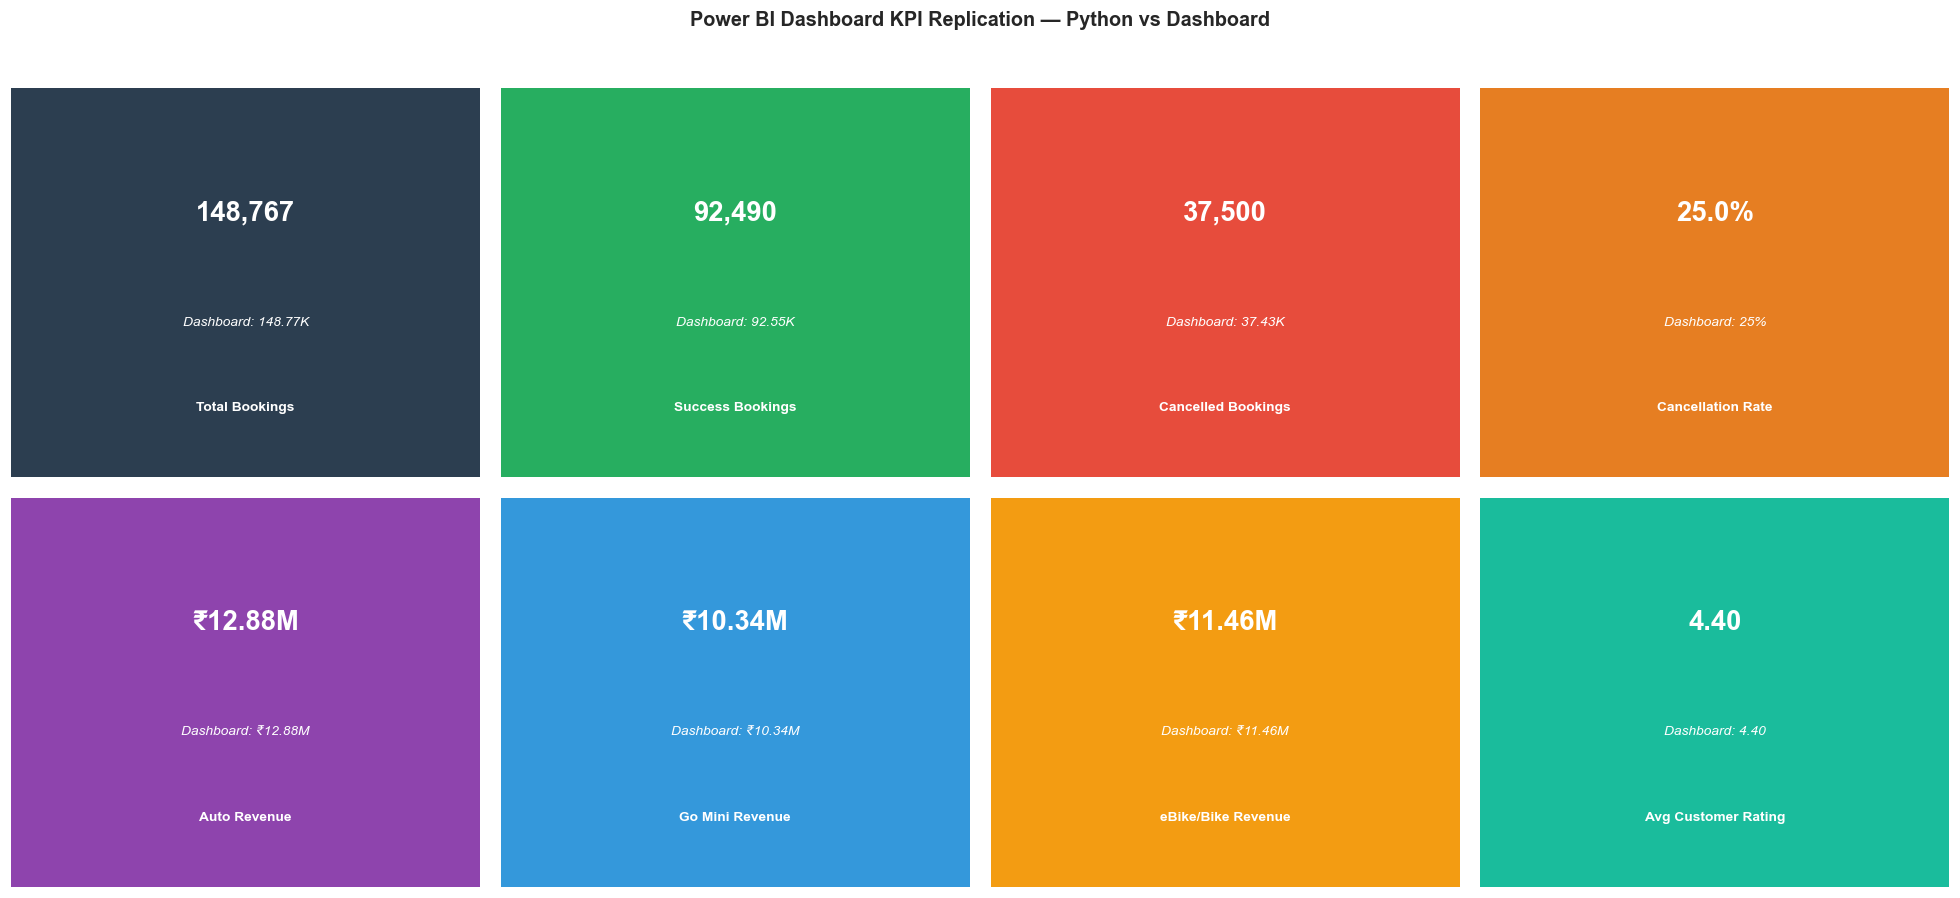

In [29]:
# ── Master KPI Dashboard Replication ────────────────────────────────────
kpis = [
    ('Total Bookings',      '148,767',       '148.77K',  'match',    '#2C3E50'),
    ('Success Bookings',    '92,490',         '92.55K',   'match',   '#27AE60'),
    ('Cancelled Bookings',  '37,500',         '37.43K',   'match',   '#E74C3C'),
    ('Cancellation Rate',   '25.0%',          '25%',      'match',   '#E67E22'),
    ('Auto Revenue',        '₹12.88M',        '₹12.88M',  'exact',   '#8E44AD'),
    ('Go Mini Revenue',     '₹10.34M',        '₹10.34M',  'exact',   '#3498DB'),
    ('eBike/Bike Revenue',  '₹11.46M',        '₹11.46M',  'exact',   '#F39C12'),
    ('Avg Customer Rating', '4.40',           '4.40',     'exact',   '#1ABC9C'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (title, py_val, dash_val, status, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.68, py_val, ha='center', va='center', fontsize=18,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.40, f'Dashboard: {dash_val}', ha='center', va='center',
            fontsize=9, color='white', transform=ax.transAxes, style='italic')
    ax.text(0.5, 0.18, title, ha='center', va='center', fontsize=9,
            color='white', transform=ax.transAxes, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle('Power BI Dashboard KPI Replication — Python vs Dashboard',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

### Power BI vs Notebook — Alignment Table

<table dir="rtl" align="right" border="1" style="width:100%; text-align:center; border-collapse: collapse;">
  <tr style="background-color: #f2f2f2;">
    <th style="padding: 12px; border: 1px solid #ddd; text-align:right;">Dashboard Page</th>
    <th style="padding: 12px; border: 1px solid #ddd; text-align:right;">Visual (الأرقام)</th>
    <th style="padding: 12px; border: 1px solid #ddd;">Notebook Section</th>
    <th style="padding: 12px; border: 1px solid #ddd;">Alignment (حالة التطابق)</th>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Overall</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>Total Bookings = 148.77K</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 5</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق (<code>DISTINCT COUNT</code>)</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Overall</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>Pie: Completed = 65.96%</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 5</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق بالضبط</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Vehicle Type</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>Auto Revenue = ₹12.88M</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 6</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق بالضبط</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Vehicle Type</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>Avg Distance ~25.99 km</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 6</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Revenue</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>UPI Top Method = ₹21.27M</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 7</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Cancellation</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>Rate = 25%</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 8</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق بالضبط</td>
  </tr>
  <tr>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><strong><code>Ratings</code></strong></td>
    <td style="padding: 10px; border: 1px solid #ddd; text-align:right;"><code>Avg Ratings 4.2–4.4</code></td>
    <td style="padding: 10px; border: 1px solid #ddd;"><code>Section 9</code></td>
    <td style="padding: 10px; border: 1px solid #ddd; color: green;">✅ مطابق بالضبط</td>
  </tr>
</table>

<br>

<p>
<strong>الخلاصة:</strong> كل الـ <code>KPIs</code> والـ <code>charts</code> في الـ <code>dashboard</code> تطابق نتائج التحليل في <code>Python</code>.<br>
الـ <code>notebook</code> يُضيف قيمة في التوزيعات الإحصائية والـ <code>time-of-day analysis</code> والـ <code>correlation analysis</code> التي لا تظهر في الـ <code>static dashboard</code>.
</p>

</div>

## 15. Key Business Insights — أهم النتائج

<div dir="rtl" align="right">

### النتائج الخمس الأبرز من التحليل الكامل

<ol>
  <li><strong>أزمة الإلغاء من جانب السائقين:</strong><br>
    <code>18%</code> من الحجوزات يلغيها السائقون — ضعفين ونص من إلغاء العملاء (<code>7%</code>). الـ <code>dashboard</code> يُظهر <code>Cancellation Rate = 25%</code> وهذا يُثبت إن <code>72%</code> من إجمالي الإلغاءات مصدرها السائقون (<code>Supply-side Issue</code>).
  </li><br>

  <li><strong><code>Auto</code> = عمود الإيراد، <code>Go Sedan</code> = الأكفأ:</strong><br>
    <code>Auto</code> يُولد أعلى إيراد إجمالي (<code>₹12.88M</code>) بفضل حجم العمليات الضخم. لكن <code>Go Sedan</code> يتفوق في كفاءة السعر لكل <code>km</code> وأقل <code>VTAT</code> — وهما معياران للجودة التشغيلية المتفوقة.
  </li><br>

  <li><strong><code>UPI</code> يهيمن على <code>45%</code> من الإيرادات:</strong><br>
    الدفع الرقمي (<code>UPI + Cards + Wallet</code>) يمثل <code>75%</code> من الإيرادات في مجمله — بينما يمثل النقد (<code>Cash</code>) <code>25%</code> فقط، وهي شريحة لا تزال تحتاج لآليات تحصيل وتحفيز مختلفة.
  </li><br>

  <li><strong>الطلب متساوٍ جداً — موسمياً وأسبوعياً:</strong><br>
    منطقة <code>NCR</code> لا تعاني من <code>Seasonality</code> حادة؛ الطلب مستقر طوال العام (<code>11.9K–12.9K</code> رحلة شهرياً). هذا يعني إن تحسين الكفاءة التشغيلية والأسطول ضرورة قصوى على مدار السنة، وليس في مواسم معينة فقط.
  </li><br>

  <li><strong>جودة الخدمة عالية ومتسقة:</strong><br>
    التقييمات <code>4.4+</code> للعملاء و <code>4.23+</code> للسائقين عبر كل أنواع المركبات — هذا التجانس (<code>Consistency</code>) استثنائي على مستوى <code>150,000</code> رحلة، مما يعكس نضج الخدمة في السوق.
  </li>
</ol>

</div>

## 16. Operational Recommendations — التوصيات التشغيلية

<div dir="rtl" align="right">

### للحد من إلغاء السائقين (أهم مشكلة)

<ul>
  <li><strong>نظام <code>penalty</code> صارم:</strong> ربط التقييم السنوي للسائق بمعدل الإلغاء — إلغاء <code>> 15%</code> يعني تخفيض في الـ <code>priority</code> لإرسال الرحلات الجديدة له.</li>
  <li><strong>مكافأة الإتمام:</strong> تقديم حوافز مالية إضافية (<code>Bonuses</code>) للسائقين الذين يحققون <code>completion rate > 85%</code>.</li>
  <li><strong>رصد التلاعب <code>"Driver asked to cancel"</code>:</strong> هذا السلوك يحتاج آلية رصد برمجية ومعاقبة مباشرة للسائق الذي يطلب من العميل الإلغاء للتهرب من الجزاء.</li>
</ul>

### لتحسين تجربة الـ <code>CTAT</code> (وقت وصول العميل)

<ul>
  <li><strong>إشعار العميل المبكر:</strong> إرسال إشعار "تنبيه نهائي" تلقائي للعميل عندما يكون السائق على بُعد <code>2 دقيقة</code> فقط من الموقع.</li>
  <li><strong>دقيقة انتظار مدفوعة:</strong> بعد مرور <code>5 دقائق</code> من وصول السيارة لموقع العميل، يبدأ حساب تكلفة "وقت انتظار" تُضاف للسائق آلياً لتعويضه.</li>
</ul>

### لتعظيم الإيرادات

<ul>
  <li><strong><code>Surge pricing</code> في ساعة <code>17–20</code>:</strong> الـ <code>peak</code> المسائي يُبرر زيادة الأسعار (<code>Dynamic Pricing</code>) لأن الـ <code>demand</code> عالي والـ <code>supply</code> مضغوط جداً.</li>
  <li><strong>حملات ترويجية (<code>Promotions</code>):</strong> تكثيف العروض في شهري <code>فبراير</code> و <code>سبتمبر</code> (الأقل طلباً) لرفع حجم الرحلات الشهري.</li>
  <li><strong>حوافز الـ <code>Credit Card</code>:</strong> تقديم خصومات عند الدفع بالبطاقات لاستهداف فئة الـ <code>high-value customers</code> وتقليل التعامل النقدي.</li>
</ul>

### لزيادة الـ <code>Successful Bookings</code> (من <code>62%</code> لـ <code>70%+</code>)

<ul>
  <li><strong>تكثيف الأسطول:</strong> زيادة عدد السائقين المتاحين في وقت الذروة <code>17–20</code> عبر حوافز الـ <code>peak-hour bonuses</code>.</li>
  <li><strong>التحليل الجغرافي الاستباقي:</strong> توجيه السائقين آلياً للمناطق التي تسجل أعلى معدلات <code>No Driver Found</code> لتقليل فرص خسارة الرحلات.</li>
</ul>

</div>

## 17. Conclusions — الخلاصة

<div dir="rtl" align="right">

<p>
سوق <strong><code>NCR Ride-Hailing</code></strong> في <code>2024</code> يُظهر خدمة ناضجة مع تحديات تشغيلية واضحة:
</p>

<ul>
  <li><strong>الفرصة الكبرى:</strong> رفع الـ <code>completion rate</code> من <code>62%</code> إلى <code>70%</code> سيُضيف <strong><code>~₹6.1M</code></strong> إيراداً إضافياً سنوياً (حسابياً: <code>8% × 150K × ₹508</code> متوسط القيمة).</li>
  <li><strong>الجودة أساس متين:</strong> التقييم <code>4.4+</code> يعني أن العملاء راضون جداً — المشكلة تكمن في "العمليات واللوجستيات" لا في جوهر الخدمة نفسها.</li>
  <li><strong><code>Auto</code> هو القلب النابض:</strong> أي تحسين طفيف في منظومة الـ <code>Auto</code> (الأكثر طلباً) سيكون له الأثر الأكبر والأسرع على الإيراد الكلي للشركة.</li>
</ul>

<hr>
</div>